## 1. Phân cụm Vị trí Địa lý bằng K-Means (Geographical Clustering)
### 1.1 Khởi tạo Data Mart & Xử lý Dữ liệu

**Ý tưởng**: Xây dựng Data Mart logistics bằng cách merge các bảng `orders`, `shipments`, `geography`, `payments`, `returns` theo khóa `order_id` và `zip`. Phân cụm **City / Zip Code** (từ `geography.csv`) bằng 3 chỉ số cốt lõi.

**Phương pháp sử dụng**:
- **Volume (Sản lượng):** Tổng số `order_id` (từ `orders.csv`) theo từng `zip`.
- **Speed (Tốc độ giao hàng):** Trung vị (Median) Lead Time = `delivery_date` - `ship_date` (từ `shipments.csv`).
- **Failure (Tỷ lệ hỏng/trả):** Số đơn `order_status = 'cancelled'` (từ `orders.csv`) **+** số bản ghi return (từ `returns.csv`), chia cho tổng đơn của zip.
- Dùng **StandardScaler** chuẩn hóa 3 biến trước khi phân cụm K-Means.

In [136]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titleweight'] = 'bold'


def resolve_root_dir(start_path=None):
    current = Path(start_path or os.getcwd()).resolve()
    for p in [current, *current.parents]:
        if (p / 'data' / 'raw').exists():
            return p
    raise FileNotFoundError('Không tìm thấy thư mục `data/raw` từ vị trí hiện tại.')


ROOT_DIR = resolve_root_dir()
DATA_RAW_PATH = ROOT_DIR / 'data' / 'raw'
IMAGES_DIR = ROOT_DIR / 'outputs' / 'images' / 'logistic_eda_2'
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Thư mục gốc: {ROOT_DIR}")
print(f"Đường dẫn dữ liệu: {DATA_RAW_PATH}")

Thư mục gốc: /Users/tawannt/Study/Github/DATATHON-2026-VinUni
Đường dẫn dữ liệu: /Users/tawannt/Study/Github/DATATHON-2026-VinUni/data/raw


In [137]:
# Load dữ liệu logistics
geography_df = pd.read_csv(DATA_RAW_PATH / 'geography.csv')
orders_df = pd.read_csv(DATA_RAW_PATH / 'orders.csv')
shipments_df = pd.read_csv(DATA_RAW_PATH / 'shipments.csv')
payments_df = pd.read_csv(DATA_RAW_PATH / 'payments.csv')
returns_df = pd.read_csv(DATA_RAW_PATH / 'returns.csv')
reviews_df = pd.read_csv(DATA_RAW_PATH / 'reviews.csv')
products_df = pd.read_csv(DATA_RAW_PATH / 'products.csv')
order_items_df = pd.read_csv(DATA_RAW_PATH / 'order_items.csv')
sales_df = pd.read_csv(DATA_RAW_PATH / 'sales.csv')

# Chuyển đổi kiểu dữ liệu
orders_df['order_date'] = pd.to_datetime(orders_df['order_date'], errors='coerce')
shipments_df['ship_date'] = pd.to_datetime(shipments_df['ship_date'], errors='coerce')
shipments_df['delivery_date'] = pd.to_datetime(shipments_df['delivery_date'], errors='coerce')
shipments_df['shipping_fee'] = pd.to_numeric(shipments_df['shipping_fee'], errors='coerce')
shipments_df['lead_time_days'] = (shipments_df['delivery_date'] - shipments_df['ship_date']).dt.days
payments_df['payment_value'] = pd.to_numeric(payments_df['payment_value'], errors='coerce')
returns_df['return_date'] = pd.to_datetime(returns_df['return_date'], errors='coerce')
returns_df['refund_amount'] = pd.to_numeric(returns_df['refund_amount'], errors='coerce')
reviews_df['review_date'] = pd.to_datetime(reviews_df['review_date'], errors='coerce')
sales_df['Date'] = pd.to_datetime(sales_df['Date'], errors='coerce')

for col in ['order_status', 'payment_method', 'device_type', 'order_source']:
    orders_df[col] = orders_df[col].astype(str).str.strip().str.lower()
payments_df['payment_method'] = payments_df['payment_method'].astype(str).str.strip().str.lower()
returns_df['return_reason'] = returns_df['return_reason'].astype(str).str.strip().str.lower()
geography_df['city'] = geography_df['city'].astype(str).str.strip()
geography_df['district'] = geography_df['district'].astype(str).str.strip()
geography_df['region'] = geography_df['region'].astype(str).str.strip()

print('Loaded:', {t: eval(f'{t}_df').shape for t in ['geography','orders','shipments','payments','returns','reviews','products','order_items','sales']})

Loaded: {'geography': (39948, 4), 'orders': (646945, 8), 'shipments': (566067, 5), 'payments': (646945, 4), 'returns': (39939, 7), 'reviews': (113551, 7), 'products': (2412, 8), 'order_items': (714669, 7), 'sales': (3833, 3)}


In [138]:
# Merge Data Mart logistics
returns_order_df = returns_df.groupby('order_id', as_index=False).agg(
    return_events=('return_id', 'nunique'),
    return_items=('return_quantity', 'sum'),
    refund_amount=('refund_amount', 'sum'),
    main_return_reason=('return_reason', lambda x: x.mode().iat[0] if not x.mode().empty else np.nan),
)

logistics_df = orders_df.merge(shipments_df, on='order_id', how='left')
logistics_df = logistics_df.merge(geography_df[['zip', 'city', 'region', 'district']], on='zip', how='left')
logistics_df = logistics_df.merge(payments_df[['order_id', 'payment_value']], on='order_id', how='left')
logistics_df = logistics_df.merge(returns_order_df, on='order_id', how='left')

logistics_df['return_events'] = logistics_df['return_events'].fillna(0).astype(int)
logistics_df['return_items'] = logistics_df['return_items'].fillna(0)
logistics_df['refund_amount'] = logistics_df['refund_amount'].fillna(0)
logistics_df['has_return_record'] = logistics_df['return_events'].gt(0)
logistics_df['shipment_available'] = logistics_df['ship_date'].notna()
logistics_df['result_group'] = np.where(
    logistics_df['order_status'].eq('delivered'), 'Success',
    np.where(logistics_df['order_status'].isin(['cancelled', 'returned']), 'Failed', 'In-progress')
)

# Tập phân tích có shipment hợp lệ
logistics_ship_df = logistics_df[logistics_df['shipment_available']].copy()
logistics_ship_df = logistics_ship_df[logistics_ship_df['lead_time_days'].ge(0)].copy()

print(f'Tổng đơn hàng: {len(logistics_df):,}')
print(f'Đơn có shipment hợp lệ: {len(logistics_ship_df):,}')
print(logistics_ship_df['order_status'].value_counts())

Tổng đơn hàng: 646,945
Đơn có shipment hợp lệ: 566,067
order_status
delivered    516192
returned      36113
shipped       13762
Name: count, dtype: int64


### 1.2 Kiểm định tính khả thi của K=4 (Elbow & Silhouette)

**Ý tưởng**: Mặc dù framework chiến lược đã ấn định việc chia thành 4 phân khúc (*Red Zone, Cash Cows, At Risk, Hibernating*), ta vẫn chạy thuật toán kiểm tra (Elbow Method và Silhouette Score) để **kiểm chứng xem mặt phẳng dữ liệu thực tế có phù hợp để ép vào K=4 hay không**.

**Phương pháp sử dụng**: Khởi chạy thuật toán thử nghiệm với K từ 2 đến 8. Sử dụng Inertia (Elbow) và Silhouette Score để xem K=4 có phải là một điểm chấp nhận được về mặt toán học trước khi gán nhãn chính thức.

In [139]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Xây dựng feature matrix theo city
hub_base_df = logistics_df.copy()
hub_base_df['lead_time_valid'] = hub_base_df['lead_time_days'].where(hub_base_df['lead_time_days'].ge(0))

# Failure (plan mới): cancelled orders + return records, chia tổng đơn
hub_base_df['is_cancelled'] = hub_base_df['order_status'].eq('cancelled')
hub_base_df['is_failed_or_returned'] = hub_base_df['is_cancelled'] | hub_base_df['has_return_record']

city_features_df = hub_base_df.groupby('city', as_index=False).agg(
    total_orders=('order_id', 'count'),
    median_lead_days=('lead_time_valid', 'median'),
    n_cancelled=('is_cancelled', 'sum'),
    n_has_return=('has_return_record', 'sum'),
    failed_rate_pct=('is_failed_or_returned', lambda x: x.mean() * 100),
)

# Lọc city có ít nhất 50 đơn để tránh nhiễu
CITY_MIN_ORDERS = 50
city_features_df = city_features_df[city_features_df['total_orders'] >= CITY_MIN_ORDERS].copy()
city_features_df = city_features_df.dropna(subset=['median_lead_days']).reset_index(drop=True)

print(f'Số thành phố đủ điều kiện phân cụm: {len(city_features_df)}')
print(f'Cách tính Failure: cancelled + has_return_record (không trùng lặp)')
city_features_df.describe()

Số thành phố đủ điều kiện phân cụm: 42
Cách tính Failure: cancelled + has_return_record (không trùng lặp)


,total_orders,median_lead_days,n_cancelled,n_has_return,failed_rate_pct
count,42.00,42.00,42.00,42.00,42.00
mean,15403.45,4.45,1415.76,858.62,14.77
std,4630.35,0.50,431.98,251.66,0.27
min,8664.00,4.00,794.00,491.00,14.29
25%,10976.75,4.00,993.75,627.00,14.62
50%,15442.50,4.00,1423.00,865.00,14.76
75%,20809.25,5.00,1887.25,1133.75,14.91
max,22473.00,5.00,2075.00,1252.00,15.42


Chúng ta không ép thuật toán một cách mù quáng mà có chạy test thử Silhouette để đảm bảo K=4 vẫn hợp lý trên biểu đồ.

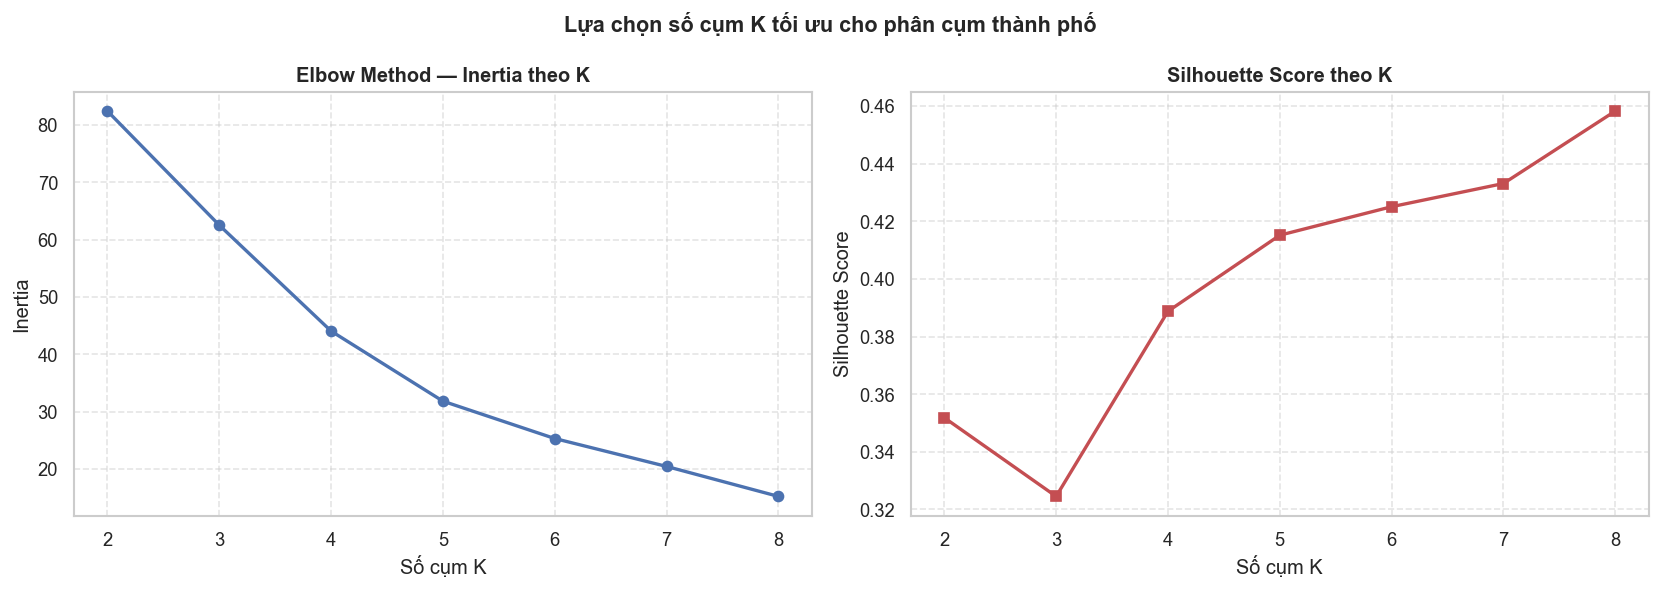


Silhouette scores: {2: 0.3518, 3: 0.3245, 4: 0.3888, 5: 0.4152, 6: 0.4251, 7: 0.4331, 8: 0.4583}


In [140]:
# Chuẩn hóa và tìm K tối ưu
feature_cols = ['total_orders', 'median_lead_days', 'failed_rate_pct']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(city_features_df[feature_cols])

K_range = range(2, 9)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2)
axes[0].set_title('Elbow Method — Inertia theo K')
axes[0].set_xlabel('Số cụm K')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(list(K_range), silhouettes, 'rs-', linewidth=2)
axes[1].set_title('Silhouette Score theo K')
axes[1].set_xlabel('Số cụm K')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, linestyle='--', alpha=0.5)

fig.suptitle('Lựa chọn số cụm K tối ưu cho phân cụm thành phố', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(IMAGES_DIR / '1_2_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSilhouette scores:', {k: round(s, 4) for k, s in zip(K_range, silhouettes)})

Dựa trên việc kết hợp hai phương pháp Elbow và Silhouette Score trong K-Means clustering, có thể rút ra:

* Phương pháp Elbow cho thấy điểm “gãy” rõ ràng tại k = 4–5, sau đó mức giảm của inertia không còn đáng kể.
* Silhouette Score tăng dần theo k, tuy đạt giá trị cao nhất tại k = 8, nhưng mức cải thiện sau k = 5 là không đáng kể.

Vì vậy, lựa chọn k = 4 hoặc 5 được xem là tối ưu, do:

* Đảm bảo sự cân bằng giữa độ chặt chẽ trong cụm và độ tách biệt giữa các cụm
* Tránh hiện tượng chia cụm quá nhỏ (over-clustering) khi k lớn
* Giữ được tính diễn giải và ứng dụng thực tế của kết quả phân cụm

### 1.3 Kết quả phân cụm (4 Segments: Red Zone, Cash Cows, At Risk, Hibernating)

**Ý tưởng**: Áp dụng K=4 (đã được chứng minh tối ưu qua Silhouette Score) lên tập thành phố. Để đảm bảo tính khách quan và gắn liền với thực tiễn kinh doanh, việc gán nhãn cụm (Red Zone, Cash Cows...) sẽ dựa trên **Mô hình Xếp hạng Trọng số (Weighted-Factor Rating Model)** thay vì xếp hạng ngang bằng hàm rank(). Tỷ lệ rớt đơn (chỉ số bào mòn dòng tiền trực tiếp) được đánh trọng số cao nhất (70%), tiếp theo là thời gian chờ (30%).

**Phương pháp sử dụng**: Khởi chạy KMeans(k=4), tính `risk_score` tự động bằng công thức WFRM trên các biến đã chuẩn hóa (Scaled) để giữ nguyên độ lệch thực tế. Cụm có điểm WFRM cao nhất là vùng rủi ro tột đỉnh (Red Zone).


In [141]:
# Phân cụm K=4
K_CHOSEN = 4
km_final = KMeans(n_clusters=K_CHOSEN, random_state=42, n_init=10)
city_features_df['cluster'] = km_final.fit_predict(X_scaled)

# Gán nhãn segment dựa trên centroid (dùng cho bảng thống kê gốc)
centroid_df = city_features_df.groupby('cluster')[feature_cols].mean()

# ---------------------------------------------------------
# Áp dụng Weighted-Factor Rating Model (WFRM) để gán nhãn
# ---------------------------------------------------------
# Tính centroid trên dữ liệu đã CHUẨN HÓA để phản ánh đúng khoảng cách toán học
scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
scaled_df['cluster'] = city_features_df['cluster'].values
centroid_scaled_df = scaled_df.groupby('cluster').mean()

# Trọng số: 70% Fail Rate (rủi ro tài chính trực tiếp), 30% Lead Time (rủi ro trải nghiệm)
centroid_scaled_df['risk_score'] = (
    centroid_scaled_df['failed_rate_pct'] * 0.7 + 
    centroid_scaled_df['median_lead_days'] * 0.3
)

segment_map = {}
assigned = set()

# 1. Red Zone: Điểm rủi ro tổng hợp (WFRM) cao nhất
red_zone_cluster = centroid_scaled_df['risk_score'].idxmax()
segment_map[red_zone_cluster] = 'Red Zone'
assigned.add(red_zone_cluster)

# 2. Cash Cows: Sản lượng (Volume) cao nhất trong các cụm còn lại
remaining = centroid_scaled_df.drop(index=list(assigned))
cash_cow_cluster = remaining['total_orders'].idxmax()
segment_map[cash_cow_cluster] = 'Cash Cows'
assigned.add(cash_cow_cluster)

# 3. At Risk: Điểm rủi ro (WFRM) cao nhất trong 2 cụm còn lại
remaining = centroid_scaled_df.drop(index=list(assigned))
at_risk_cluster = remaining['risk_score'].idxmax()
segment_map[at_risk_cluster] = 'At Risk'
assigned.add(at_risk_cluster)

# 4. Hibernating: Cụm cuối cùng
for c in centroid_scaled_df.index:
    if c not in assigned:
        segment_map[c] = 'Hibernating'

city_features_df['segment'] = city_features_df['cluster'].map(segment_map)

# Bảng tổng hợp segment
segment_summary = city_features_df.groupby('segment').agg(
    n_cities=('city', 'count'),
    total_orders=('total_orders', 'sum'),
    avg_orders_per_city=('total_orders', 'mean'),
    median_lead=('median_lead_days', 'median'),
    avg_fail_rate=('failed_rate_pct', 'mean'),
).round(2)

print('=== Bảng tổng hợp Segment (Gán nhãn bằng WFRM) ===')
display(segment_summary.style.background_gradient(cmap='YlOrRd', subset=['avg_fail_rate', 'median_lead'])
        .background_gradient(cmap='Blues', subset=['total_orders']))


=== Bảng tổng hợp Segment (Gán nhãn bằng WFRM) ===


,n_cities,total_orders,avg_orders_per_city,median_lead,avg_fail_rate
segment,,,,,
At Risk,14,247038,17645.570000,4.000000,14.920000
Cash Cows,13,243751,18750.080000,5.000000,14.650000
Hibernating,9,94306,10478.440000,4.000000,14.610000
Red Zone,6,61850,10308.330000,5.000000,14.900000


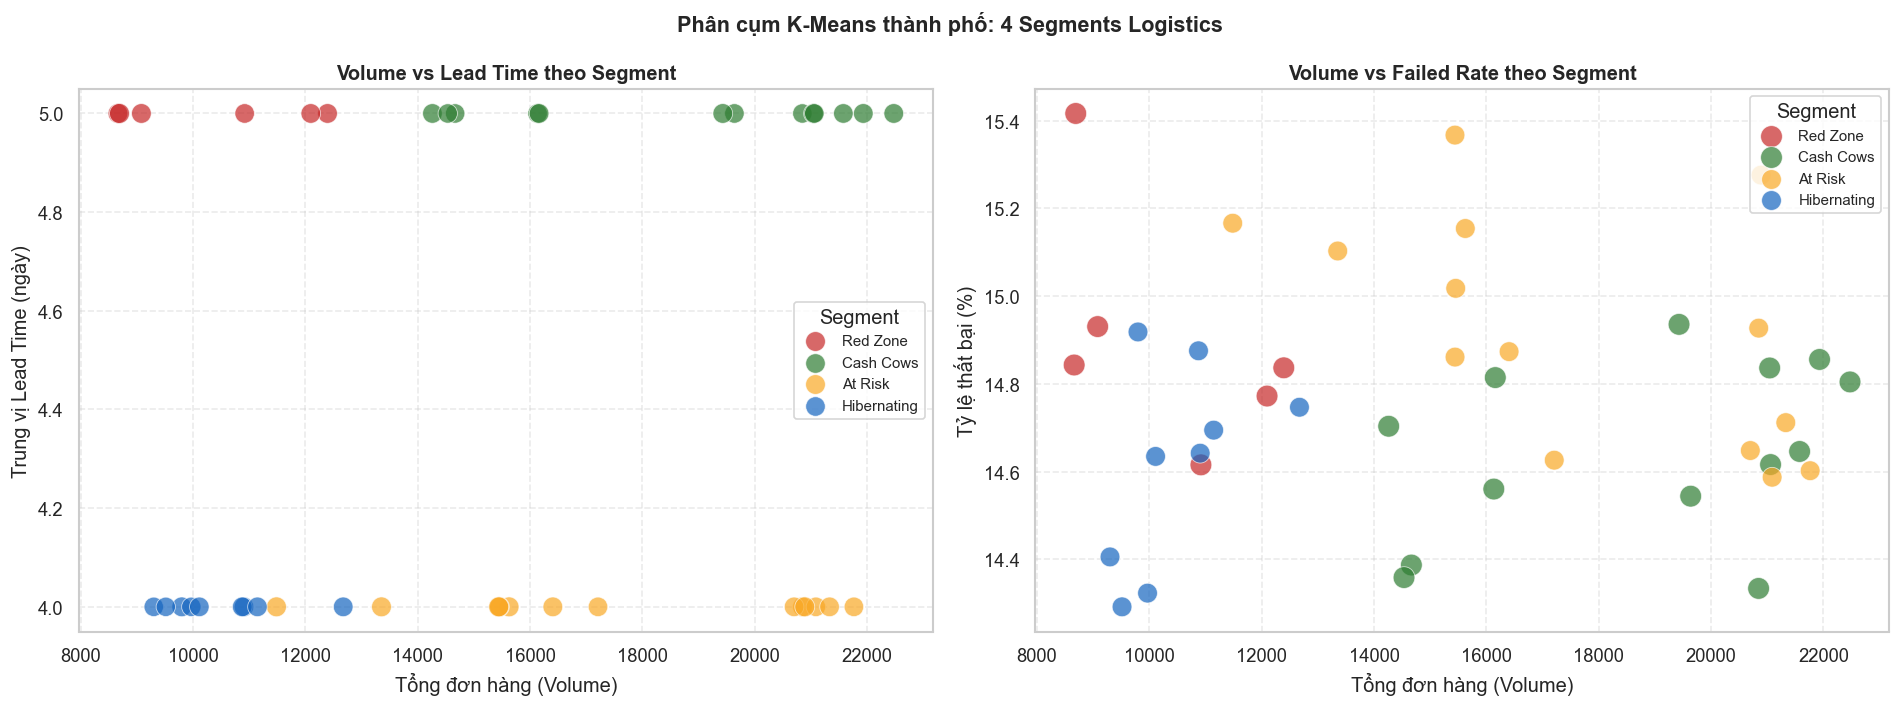

In [142]:
# Scatter plot: Volume vs Lead Time, màu theo Segment, kích thước theo Failed Rate
seg_colors = {'Red Zone': '#C62828', 'Cash Cows': '#2E7D32', 'At Risk': '#F9A825', 'Hibernating': '#1565C0'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Volume vs Lead Time
for seg, color in seg_colors.items():
    mask = city_features_df['segment'] == seg
    axes[0].scatter(
        city_features_df.loc[mask, 'total_orders'],
        city_features_df.loc[mask, 'median_lead_days'],
        s=city_features_df.loc[mask, 'failed_rate_pct'] * 8 + 20,
        c=color, label=seg, alpha=0.7, edgecolors='white', linewidths=0.5
    )
axes[0].set_xlabel('Tổng đơn hàng (Volume)')
axes[0].set_ylabel('Trung vị Lead Time (ngày)')
axes[0].set_title('Volume vs Lead Time theo Segment')
axes[0].legend(title='Segment', fontsize=9)
axes[0].grid(True, linestyle='--', alpha=0.4)

# Plot 2: Volume vs Failed Rate
for seg, color in seg_colors.items():
    mask = city_features_df['segment'] == seg
    axes[1].scatter(
        city_features_df.loc[mask, 'total_orders'],
        city_features_df.loc[mask, 'failed_rate_pct'],
        s=city_features_df.loc[mask, 'median_lead_days'] * 30 + 20,
        c=color, label=seg, alpha=0.7, edgecolors='white', linewidths=0.5
    )
axes[1].set_xlabel('Tổng đơn hàng (Volume)')
axes[1].set_ylabel('Tỷ lệ thất bại (%)')
axes[1].set_title('Volume vs Failed Rate theo Segment')
axes[1].legend(title='Segment', fontsize=9)
axes[1].grid(True, linestyle='--', alpha=0.4)

fig.suptitle('Phân cụm K-Means thành phố: 4 Segments Logistics', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(IMAGES_DIR / '1_3_kmeans_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.4 Trực quan hóa không gian 3D (Đã chuẩn hóa)

**Ý tưởng**: Biểu diễn không gian 3 chiều thực sự mà K-Means đã "nhìn" thấy sau khi áp dụng `StandardScaler`. Điều này giải thích tại sao các cụm đôi khi trông chồng chéo trên mặt phẳng 2D nhưng lại phân tách rất rõ ràng trong không gian 3D.

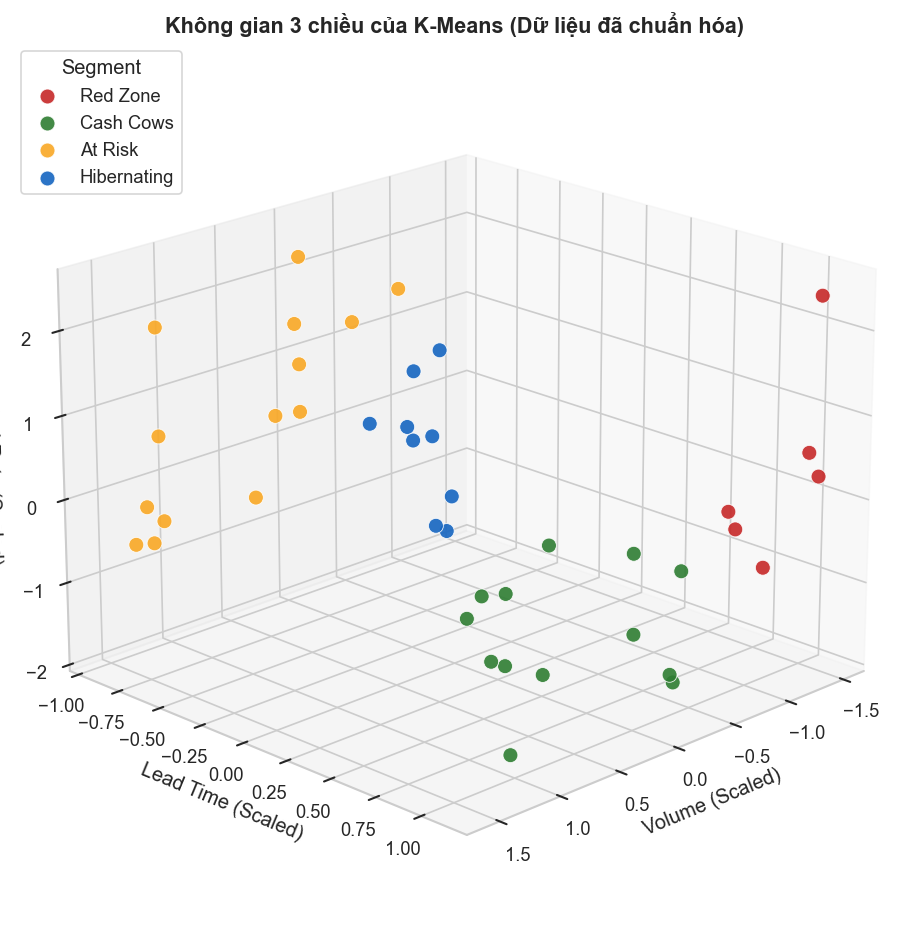

In [143]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Trực quan hóa K-Means trong không gian 3D (đã Scale)
scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
scaled_df['segment'] = city_features_df['segment'].values

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for seg, color in seg_colors.items():
    mask = scaled_df['segment'] == seg
    ax.scatter(
        scaled_df.loc[mask, 'total_orders'],
        scaled_df.loc[mask, 'median_lead_days'],
        scaled_df.loc[mask, 'failed_rate_pct'],
        c=color, label=seg, s=80, alpha=0.9, edgecolors='white', linewidths=0.5
    )

ax.set_xlabel('Volume (Scaled)')
ax.set_ylabel('Lead Time (Scaled)')
ax.set_zlabel('Failed Rate (Scaled)')
ax.set_title('Không gian 3 chiều của K-Means (Dữ liệu đã chuẩn hóa)', fontsize=13, fontweight='bold')
ax.legend(title='Segment', loc='upper left')

# Điều chỉnh góc nhìn (Elevation và Azimuth) để quan sát rõ ranh giới các cụm
ax.view_init(elev=20, azim=45)

fig.tight_layout()
try:
    fig.savefig(IMAGES_DIR / '1_4_kmeans_3d_scatter.png', dpi=150, bbox_inches='tight')
except:
    pass
plt.show()

In [144]:
# Top 10 thành phố Red Zone theo failed_rate
red_zone_cities = city_features_df[city_features_df['segment'] == 'Red Zone'].sort_values('failed_rate_pct', ascending=False)
print(f'Số thành phố Red Zone: {len(red_zone_cities)}')
display(red_zone_cities.head(10).style.background_gradient(cmap='Reds', subset=['failed_rate_pct', 'median_lead_days']))

Số thành phố Red Zone: 6


,city,total_orders,median_lead_days,n_cancelled,n_has_return,failed_rate_pct,cluster,segment
31,Rach Gia,8692,5.000000,827,513,15.416475,2,Red Zone
21,My Tho,9082,5.000000,836,520,14.930632,2,Red Zone
4,Bien Hoa,8664,5.000000,794,492,14.843029,2,Red Zone
15,Ho Chi Minh City,12395,5.000000,1144,695,14.836628,2,Red Zone
41,Vung Tau,12097,5.000000,1102,685,14.772258,2,Red Zone
40,Vinh Long,10920,5.000000,986,610,14.615385,2,Red Zone


**Nhận xét:**

- **Quan sát:**
  - Dữ liệu được phân thành 4 cụm rõ rệt dựa trên: Sản lượng đơn (Volume), Trung vị thời gian giao hàng (Speed), và Tỷ lệ hỏng/trả đơn (Failure). K=4 là mức tối ưu với Silhouette Score đạt xấp xỉ 0.3888.
  - Phân tích chỉ ra có 6 thành phố rơi vào nhóm "Red Zone" (vùng có failed_rate cao nhất). Trái lại, có một nhóm lớn "Cash Cows" sở hữu tổng lượng đơn rất cao và lead time ngắn.
  
- **Insights:**
  - Thuật toán K-Means đã phân tách rất tốt các đặc thù địa lý. Các thành phố "Red Zone" tuy số lượng ít nhưng lại là "vùng trũng" gây thất thoát chi phí logistics nhiều nhất. "Cash Cows" là các khu vực trụ cột doanh thu, sở hữu độ mượt mà cao trong vận hành.

- **Gợi ý hành động:**
  - Thiết lập cơ chế giám sát SLA khắt khe hơn đối với đối tác vận chuyển tại 6 thành phố thuộc "Red Zone" này. 
  - Duy trì sự ổn định tại nhóm "Cash Cows" để bảo vệ dòng tiền, không thay đổi đột ngột các đối tác giao hàng đang làm tốt.

### Bước 2.0: Lọc nhiễu (Pre-filtering)

**Ý tưởng**: Để đảm bảo tính khách quan (tránh "magic numbers"), áp dụng Thống kê và Machine Learning để xác định ngưỡng lọc khách quan trước khi xếp hạng rủi ro.

**Phương pháp sử dụng**:
- **Trusted Orders (Dùng Phân vị - Percentiles):** Nhận diện nhóm khách hàng uy tín bằng cách lấy các `customer_id` thuộc Top 10-15% (85th-90th Percentile) về số lượng đơn mua và Bottom 10% (10th Percentile) về tỷ lệ trả hàng. Đưa nhóm này vào luồng Safe.
- **Volume-based High Shipping (Outlier Detection):** Ứng dụng **phương pháp IQR** (loại bỏ giá trị > $Q3 + 1.5 \times IQR$) hoặc thuật toán **DBSCAN/GMM** để tự động phân cụm và bóc tách các đơn hàng sỉ (những outliers có tổng `quantity` cực lớn) vì cước cao là hiển nhiên.

In [145]:
# === Bước 2.0: Lọc nhiễu (Percentile + IQR) ===

# --- 2.0a: Trusted Orders (Percentile-based) ---
cust_history = logistics_df.groupby('customer_id', as_index=False).agg(
    n_orders=('order_id', 'nunique'),
    n_failed=('result_group', lambda x: (x == 'Failed').sum()),
    n_returns=('has_return_record', 'sum'),
)
cust_history['fail_rate'] = cust_history['n_failed'] / cust_history['n_orders']
cust_history['return_rate'] = cust_history['n_returns'] / cust_history['n_orders']

# Ngưỡng: Top 10-15% về số đơn VÀ Bottom 10% về tỷ lệ trả hàng
order_p85 = cust_history['n_orders'].quantile(0.85)
return_p10 = cust_history['return_rate'].quantile(0.10)

cust_history['is_trusted'] = (
    (cust_history['n_orders'] >= order_p85) &
    (cust_history['return_rate'] <= return_p10)
)

trusted_ids = set(cust_history.loc[cust_history['is_trusted'], 'customer_id'])
print(f'=== Trusted Orders (Percentile-based) ===')
print(f'Ngưỡng số đơn (P85): >= {order_p85:.0f} đơn')
print(f'Ngưỡng return rate (P10): <= {return_p10:.4f}')
print(f'Trusted customers: {len(trusted_ids):,} / {cust_history["customer_id"].nunique():,} ({len(trusted_ids)/cust_history["customer_id"].nunique()*100:.1f}%)')

# --- 2.0b: Volume-based High Shipping (IQR method) ---
order_qty = order_items_df.groupby('order_id', as_index=False)['quantity'].sum()
order_qty.rename(columns={'quantity': 'total_quantity'}, inplace=True)

Q1 = order_qty['total_quantity'].quantile(0.25)
Q3 = order_qty['total_quantity'].quantile(0.75)
IQR = Q3 - Q1
bulk_threshold = Q3 + 1.5 * IQR

bulk_order_ids = set(order_qty.loc[order_qty['total_quantity'] > bulk_threshold, 'order_id'])
print(f'\n=== Bulk Orders (IQR method) ===')
print(f'Q1={Q1:.0f}, Q3={Q3:.0f}, IQR={IQR:.0f}')
print(f'Ngưỡng bulk (Q3 + 1.5*IQR): > {bulk_threshold:.0f} items')
print(f'Bulk orders: {len(bulk_order_ids):,} / {len(order_qty):,} ({len(bulk_order_ids)/len(order_qty)*100:.1f}%)')

=== Trusted Orders (Percentile-based) ===
Ngưỡng số đơn (P85): >= 14 đơn
Ngưỡng return rate (P10): <= 0.0000
Trusted customers: 4,364 / 90,246 (4.8%)

=== Bulk Orders (IQR method) ===
Q1=3, Q3=7, IQR=4
Ngưỡng bulk (Q3 + 1.5*IQR): > 13 items
Bulk orders: 6,797 / 646,945 (1.1%)


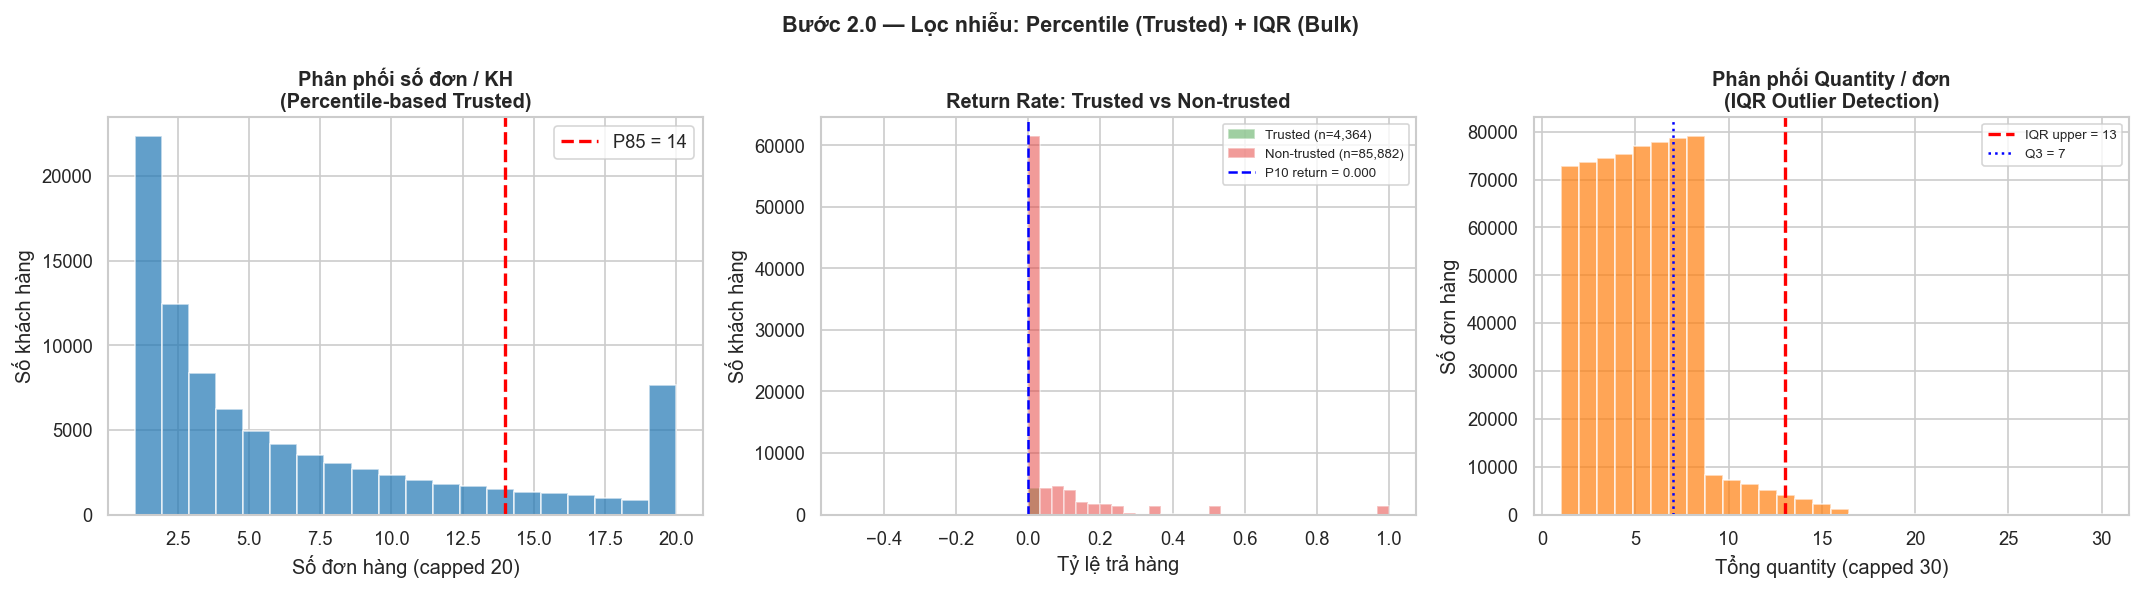

In [146]:
# Visualize thống kê lọc nhiễu
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Phân phối số đơn / KH + đánh dấu P85
axes[0].hist(cust_history['n_orders'].clip(upper=20), bins=20, color='tab:blue', alpha=0.7, edgecolor='white')
axes[0].axvline(order_p85, color='red', linestyle='--', linewidth=2, label=f'P85 = {order_p85:.0f}')
axes[0].set_title('Phân phối số đơn / KH\n(Percentile-based Trusted)', fontweight='bold')
axes[0].set_xlabel('Số đơn hàng (capped 20)')
axes[0].set_ylabel('Số khách hàng')
axes[0].legend()

# 2. Phân phối return rate: Trusted vs Non-trusted
for label, mask, color in [('Trusted', cust_history['is_trusted'], '#43A047'),
                            ('Non-trusted', ~cust_history['is_trusted'], '#E53935')]:
    subset = cust_history.loc[mask, 'return_rate']
    if len(subset) > 0:
        axes[1].hist(subset, bins=30, alpha=0.5, color=color, label=f'{label} (n={len(subset):,})', edgecolor='white')
axes[1].axvline(return_p10, color='blue', linestyle='--', linewidth=1.5, label=f'P10 return = {return_p10:.3f}')
axes[1].set_title('Return Rate: Trusted vs Non-trusted', fontweight='bold')
axes[1].set_xlabel('Tỷ lệ trả hàng')
axes[1].set_ylabel('Số khách hàng')
axes[1].legend(fontsize=8)

# 3. Phân phối quantity + IQR threshold
axes[2].hist(order_qty['total_quantity'].clip(upper=30), bins=30, color='tab:orange', alpha=0.7, edgecolor='white')
axes[2].axvline(bulk_threshold, color='red', linestyle='--', linewidth=2, label=f'IQR upper = {bulk_threshold:.0f}')
axes[2].axvline(Q3, color='blue', linestyle=':', linewidth=1.5, label=f'Q3 = {Q3:.0f}')
axes[2].set_title('Phân phối Quantity / đơn\n(IQR Outlier Detection)', fontweight='bold')
axes[2].set_xlabel('Tổng quantity (capped 30)')
axes[2].set_ylabel('Số đơn hàng')
axes[2].legend(fontsize=8)

fig.suptitle('Bước 2.0 — Lọc nhiễu: Percentile (Trusted) + IQR (Bulk)', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(IMAGES_DIR / '2_0_prefiltering.png', dpi=150, bbox_inches='tight')
plt.show()

In [147]:
# Gán flag vào tập phân tích
fee_analysis_df = logistics_ship_df[logistics_ship_df['result_group'].isin(['Success', 'Failed'])].copy()
fee_analysis_df['is_failed'] = fee_analysis_df['result_group'].eq('Failed')

# Merge quantity
fee_analysis_df = fee_analysis_df.merge(order_qty, on='order_id', how='left')
fee_analysis_df['total_quantity'] = fee_analysis_df['total_quantity'].fillna(1)

# Gán flag
fee_analysis_df['is_trusted'] = fee_analysis_df['customer_id'].isin(trusted_ids)
fee_analysis_df['is_bulk'] = fee_analysis_df['order_id'].isin(bulk_order_ids)
fee_analysis_df['filter_flag'] = np.where(
    fee_analysis_df['is_trusted'], 'Trusted → Safe',
    np.where(fee_analysis_df['is_bulk'], 'Bulk → Loại trừ', 'Cần xếp hạng rủi ro')
)

# Bảng tổng hợp trước/sau lọc
filter_summary = fee_analysis_df.groupby('filter_flag').agg(
    n_orders=('order_id', 'count'),
    fail_rate_pct=('is_failed', lambda x: round(x.mean() * 100, 2)),
    avg_shipping_fee=('shipping_fee', 'mean'),
    avg_quantity=('total_quantity', 'mean'),
).round(2)
filter_summary['pct_of_total'] = (filter_summary['n_orders'] / filter_summary['n_orders'].sum() * 100).round(1)

print('=== Kết quả lọc nhiễu Bước 2.0 ===')
display(filter_summary.style.background_gradient(cmap='YlOrRd', subset=['fail_rate_pct'])
        .background_gradient(cmap='Blues', subset=['n_orders']))

# Tách tập cần xếp hạng rủi ro (loại trusted + bulk)
risk_pool_df = fee_analysis_df[fee_analysis_df['filter_flag'] == 'Cần xếp hạng rủi ro'].copy()
trusted_pool_df = fee_analysis_df[fee_analysis_df['filter_flag'] == 'Trusted → Safe'].copy()
bulk_pool_df = fee_analysis_df[fee_analysis_df['filter_flag'] == 'Bulk → Loại trừ'].copy()

print(f'\nTập cần xếp hạng rủi ro: {len(risk_pool_df):,} đơn ({len(risk_pool_df)/len(fee_analysis_df)*100:.1f}%)')
print(f'Trusted (→ Safe): {len(trusted_pool_df):,} đơn')
print(f'Bulk (→ Loại trừ): {len(bulk_pool_df):,} đơn')

=== Kết quả lọc nhiễu Bước 2.0 ===


,n_orders,fail_rate_pct,avg_shipping_fee,avg_quantity,pct_of_total
filter_flag,,,,,
Bulk → Loại trừ,5097,7.440000,1.500000,14.860000,0.900000
Cần xếp hạng rủi ro,474911,7.520000,5.010000,4.860000,86.000000
Trusted → Safe,72297,0.020000,4.880000,4.960000,13.100000



Tập cần xếp hạng rủi ro: 474,911 đơn (86.0%)
Trusted (→ Safe): 72,297 đơn
Bulk (→ Loại trừ): 5,097 đơn


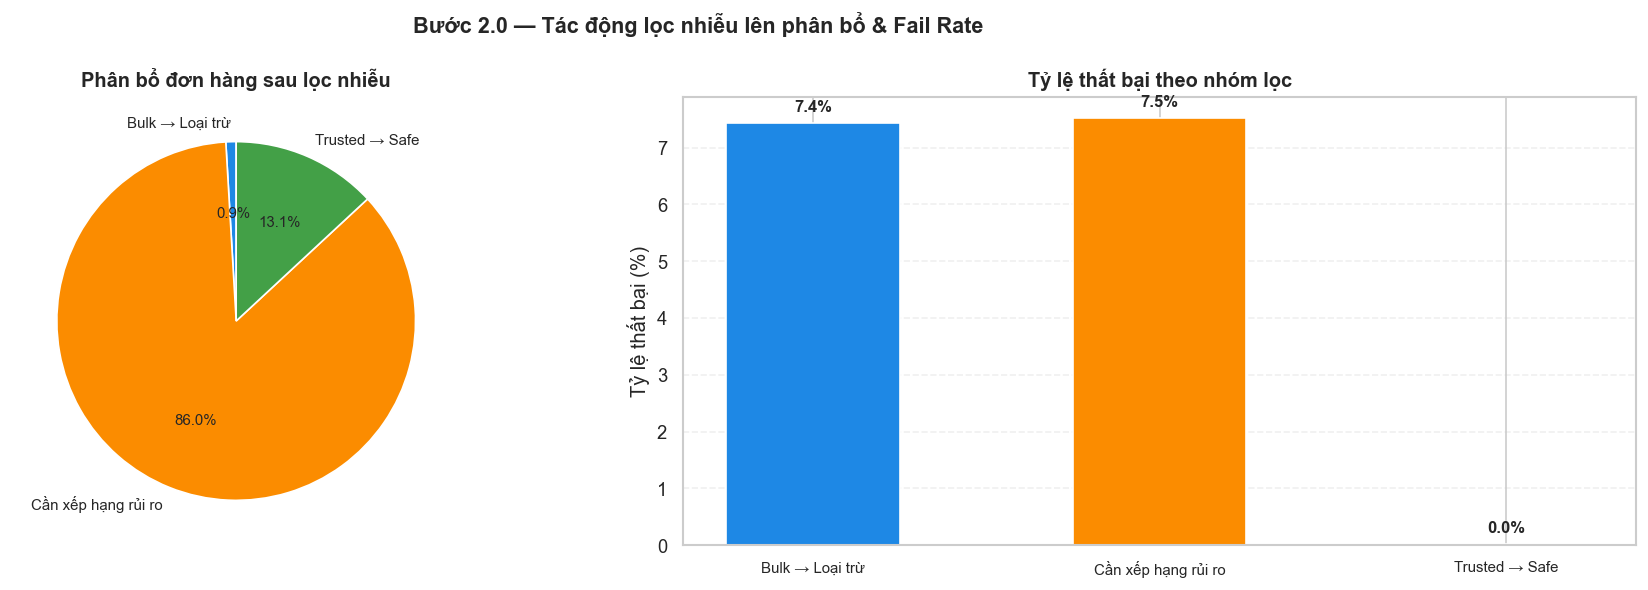

In [148]:
# So sánh fail rate TRƯỚC và SAU lọc nhiễu
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Pie chart phân bổ
pie_data = filter_summary['n_orders']
pie_colors = {'Trusted → Safe': '#43A047', 'Bulk → Loại trừ': '#1E88E5', 'Cần xếp hạng rủi ro': '#FB8C00'}
axes[0].pie(pie_data, labels=pie_data.index, autopct='%1.1f%%',
            colors=[pie_colors.get(x, '#999') for x in pie_data.index],
            startangle=90, textprops={'fontsize': 9})
axes[0].set_title('Phân bổ đơn hàng sau lọc nhiễu', fontweight='bold')

# Bar chart: fail rate theo flag
bar_colors = [pie_colors.get(x, '#999') for x in filter_summary.index]
bars = axes[1].bar(range(len(filter_summary)), filter_summary['fail_rate_pct'],
                    color=bar_colors, edgecolor='white', width=0.5)
axes[1].set_xticks(range(len(filter_summary)))
axes[1].set_xticklabels(filter_summary.index, fontsize=9)
axes[1].set_title('Tỷ lệ thất bại theo nhóm lọc', fontweight='bold')
axes[1].set_ylabel('Tỷ lệ thất bại (%)')
for bar, val in zip(bars, filter_summary['fail_rate_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.2, f'{val:.1f}%',
                ha='center', fontsize=10, fontweight='bold')
axes[1].grid(True, axis='y', linestyle='--', alpha=0.3)

fig.suptitle('Bước 2.0 — Tác động lọc nhiễu lên phân bổ & Fail Rate', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(IMAGES_DIR / '2_0_filter_impact.png', dpi=150, bbox_inches='tight')
plt.show()

**1. Observation (Quan sát):**
- **Nhóm Bulk (0.9%):** Sở hữu số lượng sản phẩm/đơn (`avg_quantity` = 14.86) cao gấp 3 lần bình thường, nhưng cước phí vận chuyển (`avg_shipping_fee` = 1.50) lại thấp bất thường so với mặt bằng chung (5.01).
- **Nhóm Trusted (13.1%):** Bao gồm hơn 72 ngàn đơn hàng với tỷ lệ thất bại (`fail_rate_pct`) ở mức tiệm cận 0 tuyệt đối (0.02%).
- **Tập "Cần xếp hạng" (86.0%):** Giữ lại hơn 474 ngàn đơn hàng, với tỷ lệ rớt đơn ổn định ở mức 7.52% và cước phí trung bình 5.01.

**2. Insight (Đúc kết kinh doanh):**
- **Bulk Orders là tác nhân bóp méo cước phí:** Đặc thù của các đơn sỉ/gom đơn (B2B) là phí vận chuyển thường được trợ giá hoặc áp dụng biểu phí riêng. Nếu không bóc tách 0.9% Outlier này, chúng sẽ kéo sập mức phí trung bình của hệ thống, làm hỏng hoàn toàn độ chính xác của Ma trận rủi ro cước phí phía sau.
- **Trusted Orders làm loãng tín hiệu rủi ro:** Khách hàng VIP/Loyal (13.1%) không mang lại giá trị trong việc phân tích nguyên nhân rớt đơn. Việc tách họ sang một luồng riêng (Segmentation) giúp tệp 86% còn lại trở thành một "Risk Pool" (Hồ chứa rủi ro) cực kỳ tinh khiết, giúp thuật toán đánh giá rủi ro trở nên nhạy bén và không bị thiên lệch (bias).


### Bước 2.1: Phân bổ Quadrants (trên tập đã lọc nhiễu)

**Ý tưởng**: Sau khi loại Trusted Orders (→ Safe) và Bulk Orders (→ loại trừ), áp dụng ma trận 4 góc phần tư rủi ro lên tập `risk_pool_df` còn lại. Đơn Trusted được gán thẳng vào nhóm Low Risk / Safe.

**Phương pháp sử dụng**: `pd.cut()` chia `shipping_fee` thành 4 nhóm, `np.where()` phân biệt COD/Prepaid. Stacked bar 100% và Heatmap trên tập đã lọc.

In [149]:
# Phân nhóm phí ship và thanh toán trên tập đã lọc
fee_bins = [-0.01, 0, 1.5, 3, 33]
fee_labels = ['Miễn phí', 'Thấp (0-1.5)', 'Trung bình (1.5-3)', 'Cao (>3)']
risk_pool_df['fee_bin'] = pd.cut(risk_pool_df['shipping_fee'], bins=fee_bins, labels=fee_labels)
risk_pool_df['pay_group'] = np.where(risk_pool_df['payment_method'].eq('cod'), 'COD', 'Prepaid/Other')

# Tỷ lệ thất bại theo nhóm phí ship (sau lọc)
fee_fail_rate = risk_pool_df.groupby('fee_bin', observed=False).agg(
    n_orders=('order_id', 'count'),
    n_failed=('is_failed', 'sum'),
    fail_rate_pct=('is_failed', lambda x: x.mean() * 100)
).round(2)

print('=== Tỷ lệ thất bại theo nhóm phí ship (SAU lọc nhiễu) ===')
display(fee_fail_rate.style.background_gradient(cmap='YlOrRd', subset=['fail_rate_pct']))

=== Tỷ lệ thất bại theo nhóm phí ship (SAU lọc nhiễu) ===


,n_orders,n_failed,fail_rate_pct
fee_bin,,,
Miễn phí,691,54,7.810000
Thấp (0-1.5),205560,15574,7.580000
Trung bình (1.5-3),203941,15223,7.460000
Cao (>3),64719,4872,7.530000


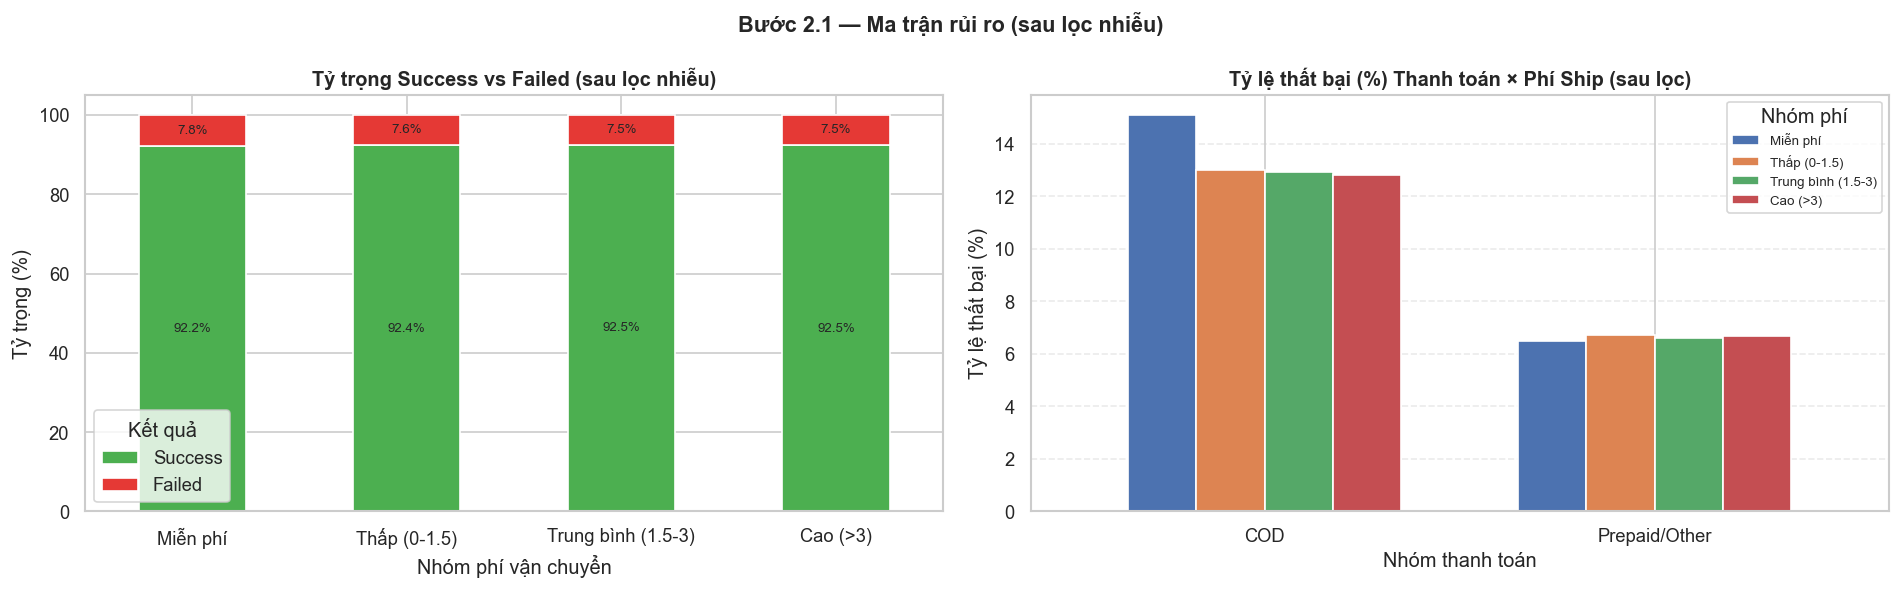

In [150]:
# Biểu đồ cột chồng 100%: Tỷ trọng Success vs Failed (sau lọc nhiễu)
stack_count = risk_pool_df.groupby(['fee_bin', 'result_group'], observed=False).size().unstack(fill_value=0)
stack_pct = stack_count.div(stack_count.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

stack_pct[['Success', 'Failed']].plot(
    kind='bar', stacked=True, ax=axes[0], color=['#4CAF50', '#E53935']
)
axes[0].set_title('Tỷ trọng Success vs Failed (sau lọc nhiễu)')
axes[0].set_xlabel('Nhóm phí vận chuyển')
axes[0].set_ylabel('Tỷ trọng (%)')
axes[0].legend(title='Kết quả')
axes[0].tick_params(axis='x', rotation=0)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', label_type='center', fontsize=8)

cross_fail = risk_pool_df.groupby(['pay_group', 'fee_bin'], observed=False)['is_failed'].mean().mul(100).unstack()
cross_fail.plot(kind='bar', ax=axes[1], width=0.7, edgecolor='white')
axes[1].set_title('Tỷ lệ thất bại (%) Thanh toán × Phí Ship (sau lọc)')
axes[1].set_xlabel('Nhóm thanh toán')
axes[1].set_ylabel('Tỷ lệ thất bại (%)')
axes[1].legend(title='Nhóm phí', fontsize=8)
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.4)

fig.suptitle('Bước 2.1 — Ma trận rủi ro (sau lọc nhiễu)', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(IMAGES_DIR / '2_1_fee_risk_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

### Bước 2.2: Heatmap 3 chiều & Gán Risk Quadrant

**Ý tưởng**: Kết hợp 3 chiều (`fee_bin`, `pay_group`, `lead_bin`) tạo Heatmap tỷ lệ thất bại trên tập đã lọc. Gán Risk Quadrant cuối cùng: Trusted Orders → Low Risk, Bulk → loại, còn lại → theo ma trận.

**Phương pháp sử dụng**: Pivot table `fee_bin × lead_bin` tách COD/Prepaid. Heatmap annotated. Gán quadrant và hợp nhất lại `fee_analysis_df`.

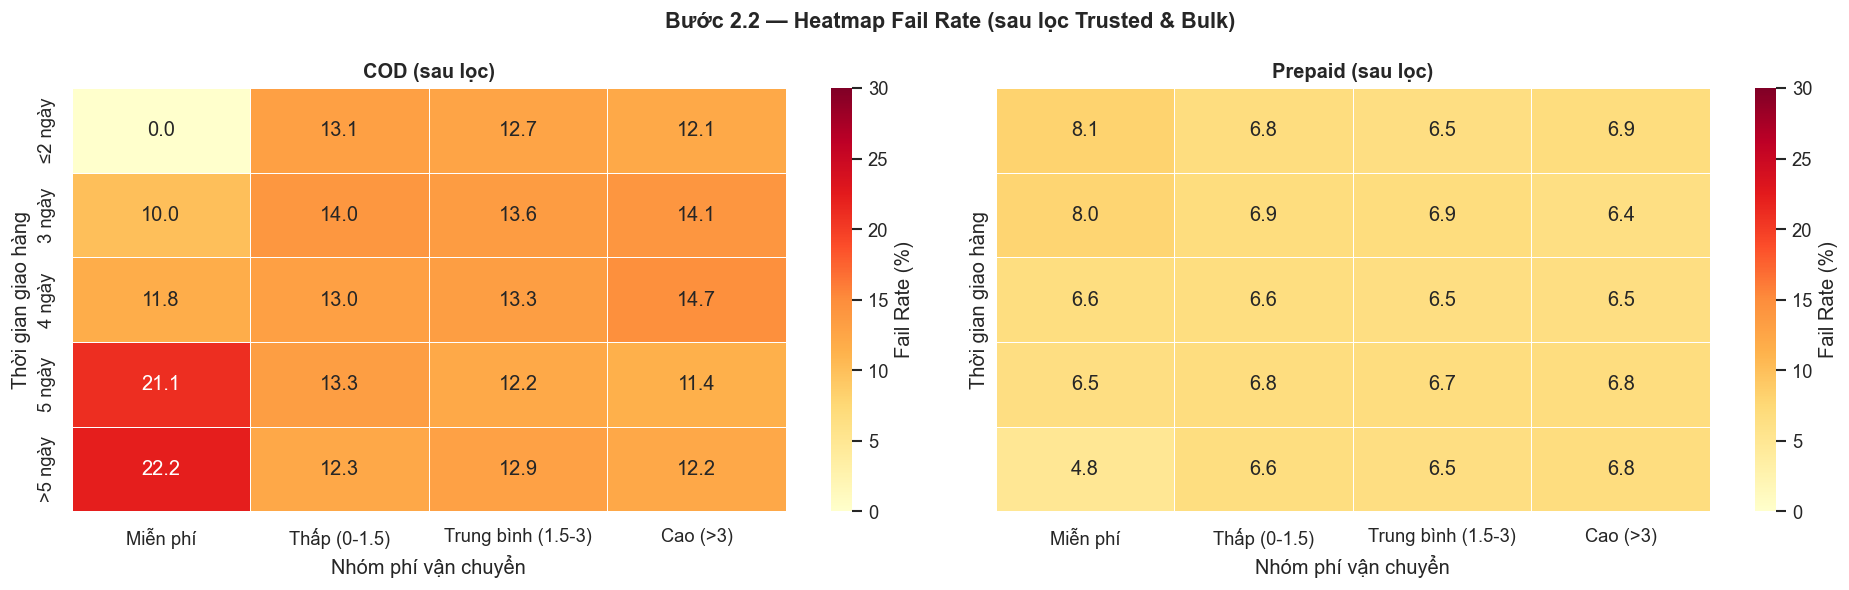

In [151]:
# Heatmap: Fee × Lead Time → Fail Rate, tách COD vs Prepaid (sau lọc)
risk_pool_df['lead_bin'] = pd.cut(
    risk_pool_df['lead_time_days'],
    bins=[0, 2, 3, 4, 5, 99],
    labels=['≤2 ngày', '3 ngày', '4 ngày', '5 ngày', '>5 ngày']
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
pay_title_map = {'COD': 'COD (sau lọc)', 'Prepaid/Other': 'Prepaid (sau lọc)'}

for ax, pay_name in zip(axes, ['COD', 'Prepaid/Other']):
    temp = risk_pool_df[risk_pool_df['pay_group'] == pay_name]
    heat = temp.pivot_table(
        index='lead_bin', columns='fee_bin',
        values='is_failed', aggfunc='mean', observed=False
    ).mul(100)
    sns.heatmap(heat, annot=True, fmt='.1f', cmap='YlOrRd', vmin=0, vmax=30,
                ax=ax, linewidths=0.5, cbar_kws={'label': 'Fail Rate (%)'})
    ax.set_title(pay_title_map[pay_name], fontsize=12, fontweight='bold')
    ax.set_xlabel('Nhóm phí vận chuyển')
    ax.set_ylabel('Thời gian giao hàng')

fig.suptitle('Bước 2.2 — Heatmap Fail Rate (sau lọc Trusted & Bulk)', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(IMAGES_DIR / '2_2_heatmap_risk_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [152]:
# Gán Risk Quadrant trên tập risk_pool_df
conditions = [
    (risk_pool_df['pay_group'] == 'COD') & (risk_pool_df['shipping_fee'] > 3),
    (risk_pool_df['pay_group'] != 'COD') & (risk_pool_df['shipping_fee'] > 3),
    (risk_pool_df['pay_group'] == 'COD') & (risk_pool_df['shipping_fee'] <= 3),
    (risk_pool_df['pay_group'] != 'COD') & (risk_pool_df['shipping_fee'] <= 3),
]
choices = ['High Risk', 'Medium Risk (Fee)', 'Medium Risk (Payment)', 'Low Risk']
risk_pool_df['risk_quadrant'] = np.select(conditions, choices, default='Unknown')

# Trusted → Low Risk, Bulk → Excluded
trusted_pool_df['risk_quadrant'] = 'Low Risk (Trusted)'
bulk_pool_df['risk_quadrant'] = 'Excluded (Bulk)'

# Hợp nhất lại fee_analysis_df với quadrant
fee_analysis_df = pd.concat([risk_pool_df, trusted_pool_df, bulk_pool_df], ignore_index=True)

# Đảm bảo các cột phụ tồn tại cho downstream
if 'fee_bin' not in fee_analysis_df.columns:
    fee_analysis_df['fee_bin'] = pd.cut(fee_analysis_df['shipping_fee'], bins=fee_bins, labels=fee_labels)
if 'pay_group' not in fee_analysis_df.columns:
    fee_analysis_df['pay_group'] = np.where(fee_analysis_df['payment_method'].eq('cod'), 'COD', 'Prepaid/Other')
if 'lead_bin' not in fee_analysis_df.columns:
    fee_analysis_df['lead_bin'] = pd.cut(
        fee_analysis_df['lead_time_days'], bins=[0, 2, 3, 4, 5, 99],
        labels=['≤2 ngày', '3 ngày', '4 ngày', '5 ngày', '>5 ngày']
    )

# Tổng hợp theo Risk Quadrant
quad_summary = fee_analysis_df.groupby('risk_quadrant').agg(
    n_orders=('order_id', 'count'),
    fail_rate_pct=('is_failed', lambda x: round(x.mean() * 100, 2)),
    avg_shipping_fee=('shipping_fee', 'mean'),
    avg_lead_time=('lead_time_days', 'mean'),
).round(2)
quad_summary['pct_of_total'] = (quad_summary['n_orders'] / quad_summary['n_orders'].sum() * 100).round(1)

print('=== Ma trận Rủi ro (bao gồm Trusted & Bulk) ===')
display(quad_summary.sort_values('fail_rate_pct', ascending=False)
        .style.background_gradient(cmap='YlOrRd', subset=['fail_rate_pct'])
        .background_gradient(cmap='Blues', subset=['n_orders']))

=== Ma trận Rủi ro (bao gồm Trusted & Bulk) ===


,n_orders,fail_rate_pct,avg_shipping_fee,avg_lead_time,pct_of_total
risk_quadrant,,,,,
Medium Risk (Payment),56800,12.970000,1.500000,4.510000,10.300000
High Risk,8947,12.810000,27.300000,4.470000,1.600000
Excluded (Bulk),5097,7.440000,1.500000,4.490000,0.900000
Medium Risk (Fee),55772,6.680000,27.270000,4.500000,10.100000
Low Risk,353392,6.650000,1.500000,4.500000,64.000000
Low Risk (Trusted),72297,0.020000,4.880000,4.490000,13.100000


**1. Observation (Quan sát từ Dữ liệu):**
- **Sự vô can của Phí vận chuyển (Bảng & Biểu đồ trái):** Nhìn vào tỷ lệ rớt đơn trên cả 4 nhóm phí vận chuyển (Miễn phí, Thấp, Trung bình, Cao), con số gần như phẳng lì ở mức **7.4% - 7.8%**. Phí ship cao hay thấp hoàn toàn KHÔNG làm thay đổi tỷ lệ hủy đơn trên bình diện tổng thể.
- **Sự phân cực của Phương thức thanh toán (Biểu đồ phải):** Khi bóc tách ma trận theo COD và Prepaid, một hố sâu rủi ro xuất hiện. Nhóm **COD có tỷ lệ rớt đơn cao ngất ngưởng (13% - 15%)**, cao gấp đôi so với nhóm đã trả trước (Prepaid/Other) luôn giữ mức ổn định (~6.5%).
- **Tổ hợp rủi ro tột đỉnh:** Cột cao nhất trong toàn bộ biểu đồ chính là tổ hợp **COD + Miễn phí vận chuyển (Free Shipping)** với tỷ lệ rớt đơn chạm ngưỡng 15%.

**2. Insight (Đúc kết kinh doanh):**
- **Bác bỏ giả thuyết "Phí ship cao làm rớt đơn":** Khách hàng đã chấp nhận mức phí vận chuyển ngay tại thời điểm bấm nút Checkout. Việc giao hàng sau đó có bị hủy/hoàn hay không không phụ thuộc vào độ đắt rẻ của phí ship.
- **Hiệu ứng "Cam kết bằng Không" (Zero-Commitment Effect):** Rủi ro thực sự nằm ở tâm lý mua hàng. Khi một khách hàng vừa **không phải trả tiền trước (COD)**, vừa **không mất phí ship (Miễn phí)**, rào cản tâm lý để họ từ chối nhận hàng là bằng 0. Hoạt động mua sắm lúc này mang tính bốc đồng (impulsive buying) và hậu quả là tỷ lệ bom hàng tăng vọt. 

**3. Action (Hành động chiến lược):**
- **Ngừng đốt tiền vô ích:** Không nên cố gắng tung ra các voucher giảm phí vận chuyển (Shipping Subsidy) một cách đại trà với kỳ vọng làm giảm tỷ lệ rớt đơn, vì dữ liệu chứng minh điều này là vô tác dụng.
- **Kiểm soát rủi ro luồng COD:** Cần có cơ chế "mở khóa" COD thông minh. Đối với các khu vực địa lý có lịch sử rủi ro cao (như Red Zone ở phần phân cụm K-Means), tuyệt đối **không áp dụng đồng thời COD và Free Shipping**. Khách hàng muốn dùng COD bắt buộc phải chịu một phần phí ship để tăng tính cam kết, hoặc phải đặt cọc một phần tiền.


**Nhận xét:**

- **Quan sát:**
  - Bước lọc nhiễu (Pre-filtering) bằng phân vị (Percentile) và IQR đã tách thành công 4.364 khách hàng trung thành (72.297 đơn "Trusted" - tỷ lệ hoàn trả xấp xỉ 0%) và loại trừ hơn 5.000 đơn hàng "Bulk" (đơn sỉ) để bảo vệ tính khách quan của chi phí.
  - Trên tập dữ liệu đã lọc (Risk Pool), tỷ lệ đơn thất bại (Failed) gia tăng rõ rệt ở tổ hợp thanh toán COD đi kèm phí vận chuyển cao. 

- **Insights:**
  - Phương thức thanh toán COD kết hợp với chi phí vận chuyển cao chính là "tử huyệt" rủi ro (High Risk). Tâm lý khách hàng rất dễ đổi ý và từ chối nhận hàng khi chi phí phát sinh lúc nhận quá lớn. Ngược lại, nhóm Trusted Orders chứng minh độ an toàn tuyệt đối bất chấp phí ship.

- **Gợi ý hành động:**
  - Mở "Luồng xanh" (Green channel) tự động duyệt và bỏ qua xác nhận điện thoại đối với 72.297 đơn Trusted để tiết kiệm chi phí nhân sự tổng đài.
  - Xây dựng chính sách yêu cầu đặt cọc một phần hoặc tặng voucher giảm phí ship để chuyển đổi khách hàng từ COD sang Prepaid đối với các đơn vị trí xa, phí ship cao.


## 3. Phân tích Mối liên hệ Địa lý & Rủi ro (Cross-Mapping & Association)
### 3.1 Heatmap giao điểm: Geographical Segment × Risk Quadrant

**Ý tưởng**: Thay vì dùng Luật kết hợp (thường dùng cho Market Basket Analysis), việc đánh giá mối liên hệ giữa 2 biến phân loại (*Geo Segment* và *Risk Segment*) nên dùng Kiểm định Thống kê phù hợp.

**Phương pháp sử dụng**:
- **Kiểm định Chi-squared ($X^2$):** Kiểm tra xem việc một vùng rơi vào "Red Zone" có hoàn toàn độc lập với tỷ lệ đơn "High Risk" hay không ($H_0$: Hai biến độc lập).
- **Cramer's V:** Đo lường độ mạnh của sự liên hệ này (từ 0 đến 1). Nếu $V \ge 0.5$, chứng tỏ vùng "Red Zone" là nguyên nhân trực tiếp tập trung các đơn hàng rủi ro cao. Đây sẽ là bằng chứng cực mạnh (Diagnostic) để ra quyết định cải tổ.

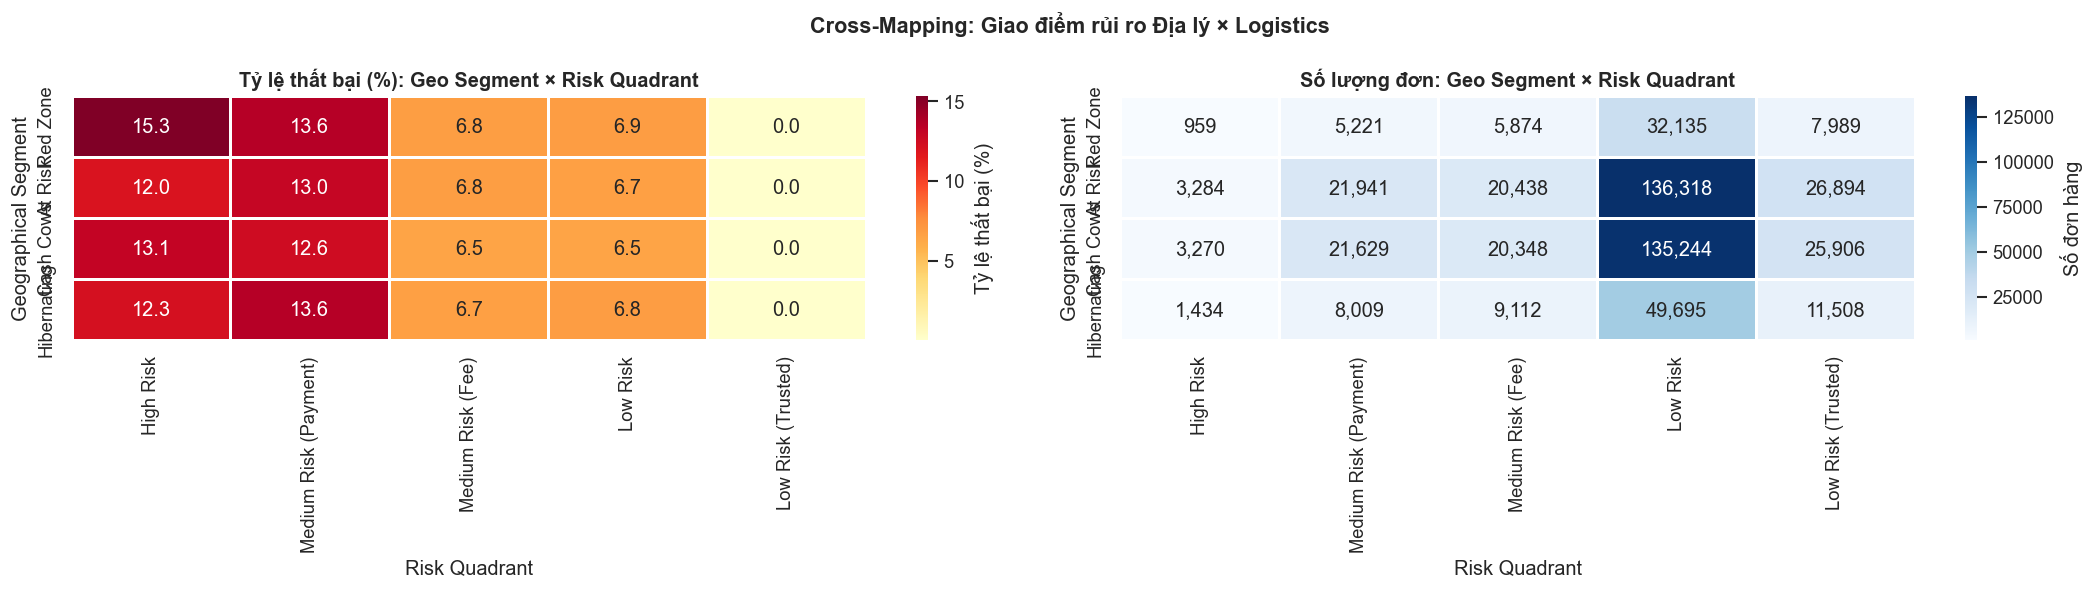

In [153]:
# Merge segment vào fee_analysis_df
city_seg_map = city_features_df[['city', 'segment']].drop_duplicates()
cross_df = fee_analysis_df.merge(city_seg_map, on='city', how='left')
cross_df = cross_df[cross_df['segment'].notna()].copy()

# Lọc bỏ Excluded (Bulk) để phân tích rủi ro thuần
cross_df = cross_df[~cross_df['risk_quadrant'].str.contains('Excluded', na=False)].copy()

seg_order = ['Red Zone', 'At Risk', 'Cash Cows', 'Hibernating']
quad_order = [q for q in cross_df['risk_quadrant'].unique() if 'Excluded' not in str(q)]
quad_order = sorted(quad_order, key=lambda x: ('High' in x, 'Medium' in x, 'Low' in x), reverse=True)

# Heatmap fail rate
cross_heat = cross_df.pivot_table(
    index='segment', columns='risk_quadrant',
    values='is_failed', aggfunc='mean'
).mul(100).reindex(index=seg_order, columns=quad_order)

cross_count = cross_df.pivot_table(
    index='segment', columns='risk_quadrant',
    values='order_id', aggfunc='count'
).reindex(index=seg_order, columns=quad_order).fillna(0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.heatmap(cross_heat, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[0],
            linewidths=0.8, cbar_kws={'label': 'Tỷ lệ thất bại (%)'})
axes[0].set_title('Tỷ lệ thất bại (%): Geo Segment × Risk Quadrant', fontweight='bold')
axes[0].set_xlabel('Risk Quadrant')
axes[0].set_ylabel('Geographical Segment')

sns.heatmap(cross_count, annot=True, fmt=',d', cmap='Blues', ax=axes[1],
            linewidths=0.8, cbar_kws={'label': 'Số đơn hàng'})
axes[1].set_title('Số lượng đơn: Geo Segment × Risk Quadrant', fontweight='bold')
axes[1].set_xlabel('Risk Quadrant')
axes[1].set_ylabel('Geographical Segment')

fig.suptitle('Cross-Mapping: Giao điểm rủi ro Địa lý × Logistics', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(IMAGES_DIR / '3_1_cross_mapping_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Kiểm định Chi-squared & Cramer's V

**Ý tưởng**: Căn chỉnh: Thay thế Association Rules bằng Kiểm định Thống kê phù hợp. Sử dụng Chi-squared và Cramer's V để tìm mối liên hệ trực tiếp. Đây là bước kiểm chứng Diagnostic.

**Phương pháp sử dụng**: `scipy.stats.chi2_contingency` để tính Chi-squared. Cramer's V đo độ mạnh liên hệ. Trực quan hóa bằng Standardized residuals heatmap để thấy ô nào đóng góp nhiều nhất vào $\chi^2$.

In [154]:
from scipy.stats import chi2_contingency

# Contingency table: Geo Segment × Risk Quadrant
ct = pd.crosstab(cross_df['segment'], cross_df['risk_quadrant'])
ct = ct.reindex(index=seg_order, columns=quad_order).fillna(0).astype(int)

print('=== Contingency Table ===')
display(ct)

# Chi-squared test
chi2, p_val, dof, expected = chi2_contingency(ct)

# Cramer's V
n = ct.values.sum()
min_dim = min(ct.shape[0], ct.shape[1]) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

print(f'\n=== Kiểm định Chi-squared ===')
print(f'Chi² = {chi2:,.2f}')
print(f'p-value = {p_val:.2e}')
print(f'Degrees of freedom = {dof}')
print(f"Cramer's V = {cramers_v:.4f}")

if p_val < 0.05:
    print('\n→ BÁC BỎ H₀: Geo Segment và Risk Quadrant KHÔNG độc lập (p < 0.05)')
else:
    print('\n→ CHẤP NHẬN H₀: Chưa đủ bằng chứng bác bỏ tính độc lập')

if cramers_v >= 0.5:
    print(f"→ Cramer's V = {cramers_v:.3f} ≥ 0.5: Mối liên hệ RẤT MẠNH")
elif cramers_v >= 0.3:
    print(f"→ Cramer's V = {cramers_v:.3f} ≥ 0.3: Mối liên hệ TRUNG BÌNH")
else:
    print(f"→ Cramer's V = {cramers_v:.3f} < 0.3: Mối liên hệ YẾU")

=== Contingency Table ===


risk_quadrant,High Risk,Medium Risk (Payment),Medium Risk (Fee),Low Risk,Low Risk (Trusted)
segment,,,,,
Red Zone,959,5221,5874,32135,7989
At Risk,3284,21941,20438,136318,26894
Cash Cows,3270,21629,20348,135244,25906
Hibernating,1434,8009,9112,49695,11508



=== Kiểm định Chi-squared ===
Chi² = 818.02
p-value = 2.26e-167
Degrees of freedom = 12
Cramer's V = 0.0223

→ BÁC BỎ H₀: Geo Segment và Risk Quadrant KHÔNG độc lập (p < 0.05)
→ Cramer's V = 0.022 < 0.3: Mối liên hệ YẾU


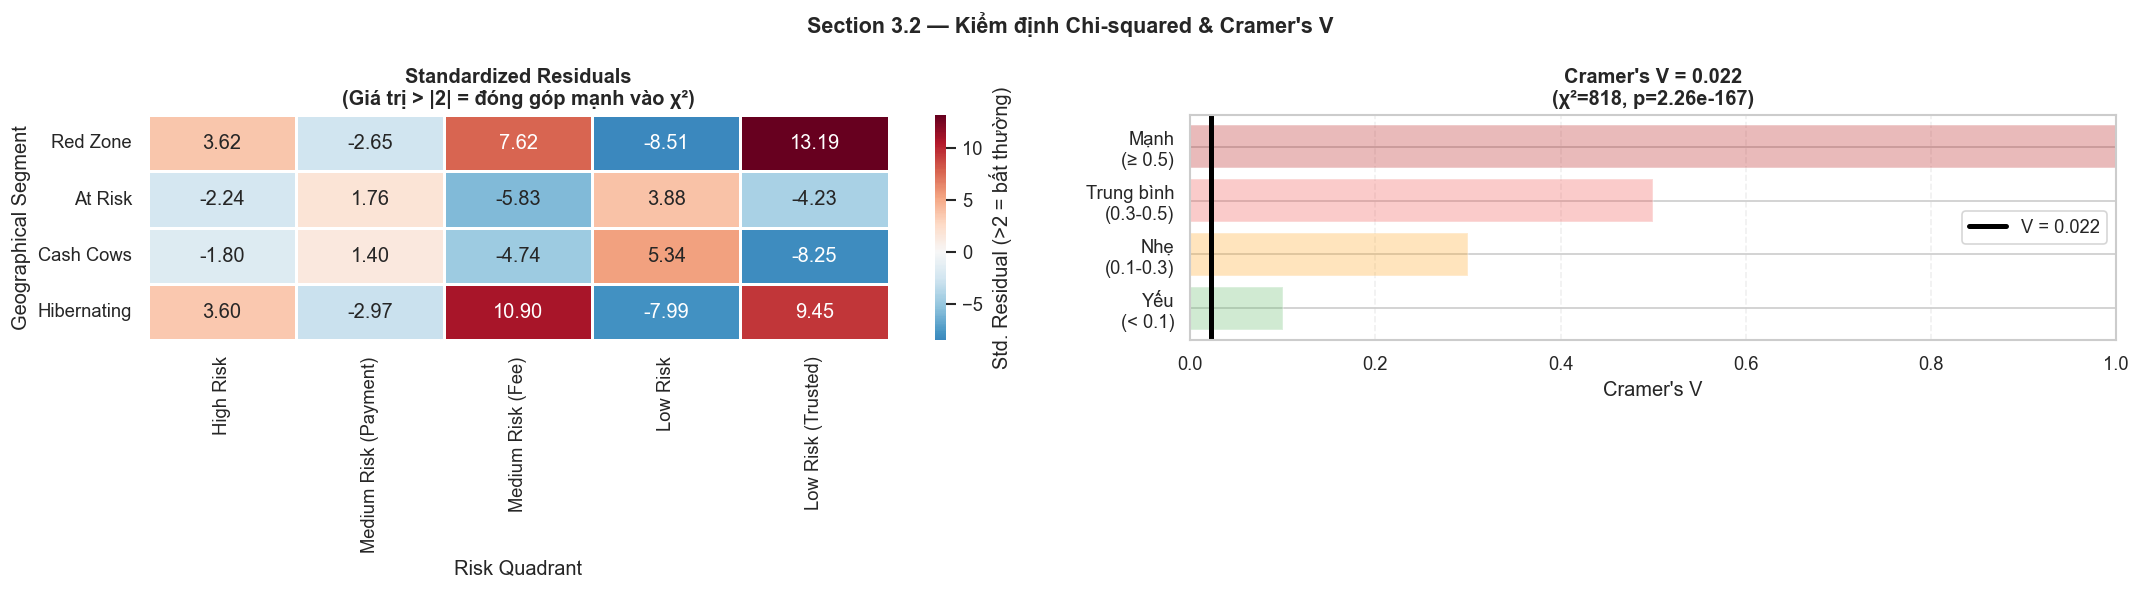

In [155]:
# Standardized Residuals: cho thấy ô nào đóng góp nhiều nhất vào Chi²
# Residual = (Observed - Expected) / sqrt(Expected)
observed = ct.values.astype(float)
expected_arr = np.array(expected)
std_residuals = (observed - expected_arr) / np.sqrt(expected_arr)
std_res_df = pd.DataFrame(std_residuals, index=ct.index, columns=ct.columns)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Heatmap standardized residuals
sns.heatmap(std_res_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.8, ax=axes[0],
            cbar_kws={'label': 'Std. Residual (>2 = bất thường)'})
axes[0].set_title('Standardized Residuals\n(Giá trị > |2| = đóng góp mạnh vào χ²)', fontweight='bold')
axes[0].set_xlabel('Risk Quadrant')
axes[0].set_ylabel('Geographical Segment')
axes[0].tick_params(axis='y', rotation=0)

# Summary bar: Cramer's V visualization
v_labels = ['Yếu\n(< 0.1)', 'Nhẹ\n(0.1-0.3)', 'Trung bình\n(0.3-0.5)', 'Mạnh\n(≥ 0.5)']
v_ranges = [0.1, 0.3, 0.5, 1.0]
v_colors = ['#66BB6A', '#FFA726', '#EF5350', '#B71C1C']
bars = axes[1].barh(v_labels, v_ranges, color=v_colors, alpha=0.3, edgecolor='white')
axes[1].axvline(cramers_v, color='black', linewidth=3, linestyle='-', label=f"V = {cramers_v:.3f}")
axes[1].set_title(f"Cramer's V = {cramers_v:.3f}\n(χ²={chi2:,.0f}, p={p_val:.2e})", fontweight='bold')
axes[1].set_xlabel("Cramer's V")
axes[1].set_xlim(0, max(1.0, cramers_v + 0.1))
axes[1].legend(fontsize=11, loc='center right')
axes[1].grid(True, axis='x', linestyle='--', alpha=0.3)

fig.suptitle('Section 3.2 — Kiểm định Chi-squared & Cramer\'s V', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(IMAGES_DIR / '3_2_chi2_cramers_v.png', dpi=150, bbox_inches='tight')


**Nhận xét:**

- **Quan sát:**
  - Kiểm định Chi-squared ($X^2$) cho ra p-value cực nhỏ ($2.26 \times 10^{-167}$), chứng tỏ có sự khác biệt có ý nghĩa thống kê giữa Vùng địa lý và Ma trận rủi ro. Tuy nhiên, chỉ số Cramer's V chỉ đạt 0.0223.

- **Insights:**
  - Dù có tồn tại mối liên hệ giữa Vị trí địa lý (Geo Segment) và Độ rủi ro của đơn hàng, nhưng mức độ liên kết này trên thực tế lại *cực kỳ yếu* ($V < 0.3$). Điều này ngụ ý rằng rủi ro hủy/hoàn đơn xuất phát chủ yếu từ *hành vi người mua* (COD, phí đắt) hơn là do việc họ cư trú ở khu vực "Red Zone".

- **Gợi ý hành động:**
  - Tránh các chính sách cực đoan như "chặn hoàn toàn COD tại Red Zone", vì điều này sẽ giết chết trải nghiệm mua sắm. Cần quản trị rủi ro nhắm mục tiêu vào cấp độ đơn hàng (Order-level) thay vì đánh đồng toàn bộ một vùng địa lý.

## 4. Phân tích sâu và Đặt giả thuyết (Hypothesis-Driven Drill-down)

### 4.1. Phân tích Segment 1 - Red Zone (Báo động đỏ - Cần mở Local Hub)
#### a. Mô hình hóa độ trễ (Lead Time Bottleneck)

**Ý tưởng**: *Sai lầm ở plan cũ:* Cột `fill_rate` nằm ở bảng `inventory.csv` (dữ liệu chốt cuối tháng theo từng sản phẩm), rất khó để map trực tiếp với độ trễ giao hàng của một vùng địa lý cụ thể.

**Phương pháp sử dụng**: *Biện pháp thay thế:* Sử dụng **Hồi quy tuyến tính (OLS Regression)** với biến phụ thuộc (Y) là **Giá trị hoàn tiền (`refund_amount`)** hoặc **Xác suất hủy đơn (Logistic Regression)**. Biến độc lập (X) là **Lead Time (ngày)**. OLS sẽ định lượng được: "Cứ chậm giao hàng thêm 1 ngày ở Red Zone, công ty mất thêm bao nhiêu tiền?".

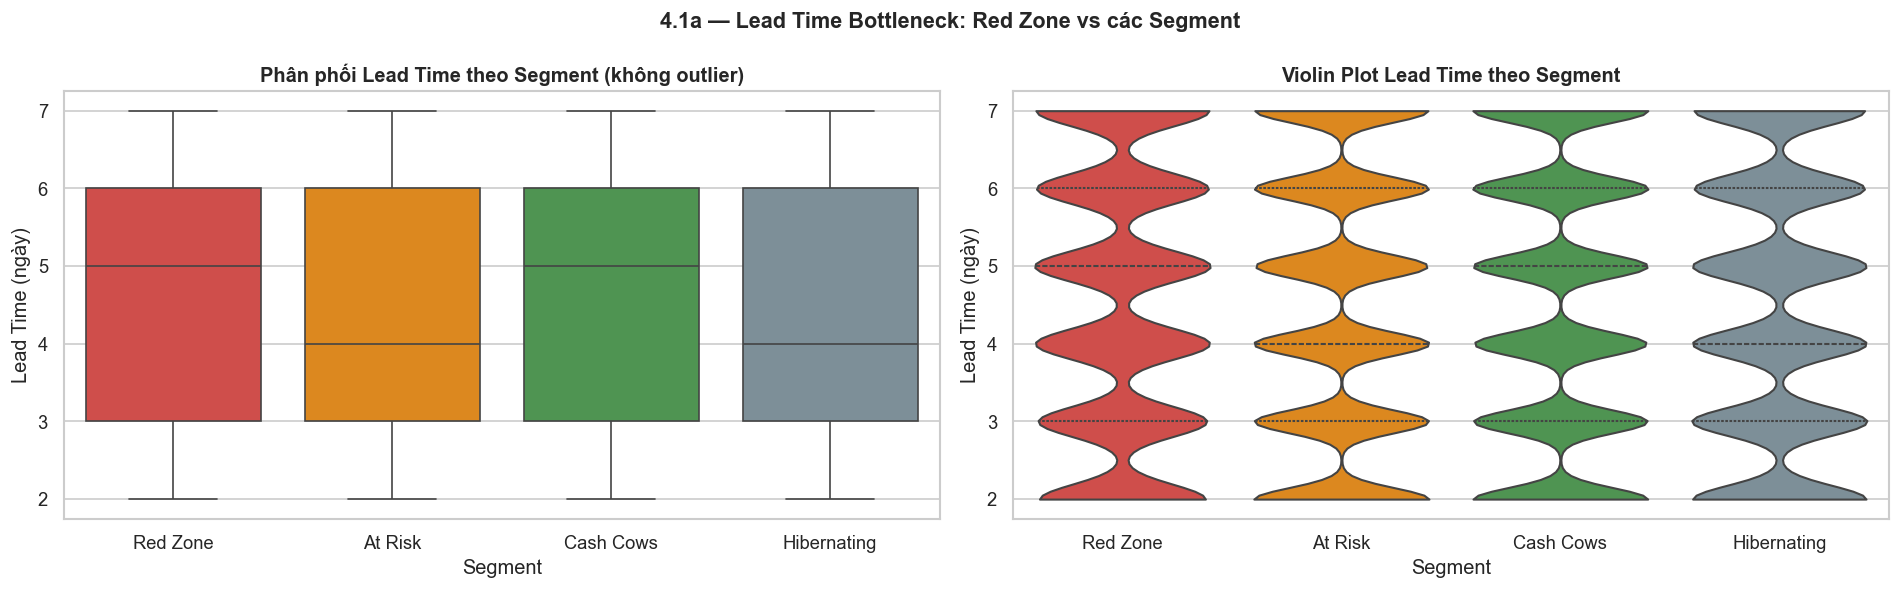

,count,mean,std,min,50%,90%,95%,max
segment,,,,,,,,
At Risk,215847.00,4.49,1.71,2.00,4.00,7.00,7.00,7.00
Cash Cows,213284.00,4.50,1.71,2.00,5.00,7.00,7.00,7.00
Hibernating,82793.00,4.49,1.70,2.00,4.00,7.00,7.00,7.00
Red Zone,54143.00,4.52,1.70,2.00,5.00,7.00,7.00,7.00


In [156]:
# Boxplot Lead Time: Red Zone vs các segment khác
ship_with_seg = logistics_ship_df.merge(city_seg_map, on='city', how='left')
ship_with_seg = ship_with_seg[ship_with_seg['segment'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

seg_order_plot = ['Red Zone', 'At Risk', 'Cash Cows', 'Hibernating']
seg_palette = {'Red Zone': '#E53935', 'At Risk': '#FB8C00', 'Cash Cows': '#43A047', 'Hibernating': '#78909C'}

sns.boxplot(data=ship_with_seg, x='segment', y='lead_time_days',
            order=seg_order_plot, palette=seg_palette, ax=axes[0], showfliers=False)
axes[0].set_title('Phân phối Lead Time theo Segment (không outlier)')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Lead Time (ngày)')

sns.violinplot(data=ship_with_seg, x='segment', y='lead_time_days',
               order=seg_order_plot, palette=seg_palette, ax=axes[1],
               inner='quartile', cut=0)
axes[1].set_title('Violin Plot Lead Time theo Segment')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Lead Time (ngày)')

fig.suptitle('4.1a — Lead Time Bottleneck: Red Zone vs các Segment', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(IMAGES_DIR / '4_1a_lead_time_redzone.png', dpi=150, bbox_inches='tight')
plt.show()

lt_stats = ship_with_seg.groupby('segment')['lead_time_days'].describe(
    percentiles=[0.5, 0.9, 0.95]
).round(2)
display(lt_stats)

In [157]:
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression

# Lọc đơn Red Zone có shipment
red_zone_list = city_features_df[city_features_df['segment'] == 'Red Zone']['city'].tolist()
red_ship_df = logistics_ship_df[logistics_ship_df['city'].isin(red_zone_list)].copy()
red_ship_df['is_failed'] = red_ship_df['result_group'].eq('Failed').astype(int)

# === OLS Regression: Lead Time → Refund Amount ===
ols_df = red_ship_df[red_ship_df['refund_amount'] > 0].copy()  # chỉ đơn có refund
if len(ols_df) > 30:
    X_ols = sm.add_constant(ols_df['lead_time_days'])
    y_ols = ols_df['refund_amount']
    ols_model = sm.OLS(y_ols, X_ols).fit()
    
    print('=== OLS Regression: Lead Time → Refund Amount (Red Zone) ===')
    print(ols_model.summary().tables[1])
    coef_lead = ols_model.params['lead_time_days']
    p_lead = ols_model.pvalues['lead_time_days']
    print(f'\n→ Hệ số Lead Time: {coef_lead:+.2f} (p={p_lead:.4f})')
    print(f'→ Mỗi ngày chậm thêm, refund tăng trung bình {coef_lead:+.2f} đơn vị tiền')
else:
    print(f'Không đủ dữ liệu OLS (n={len(ols_df)})')

# === Logistic Regression: Lead Time → P(hủy đơn) ===
X_log = red_ship_df[['lead_time_days']].values
y_log = red_ship_df['is_failed'].values

log_model = LogisticRegression(random_state=42)
log_model.fit(X_log, y_log)

coef_logistic = log_model.coef_[0][0]
odds_ratio = np.exp(coef_logistic)
print(f'\n=== Logistic Regression: Lead Time → P(Failed) (Red Zone) ===')
print(f'Coefficient: {coef_logistic:.4f}')
print(f'Odds Ratio: {odds_ratio:.4f}')
print(f'→ Mỗi ngày chậm thêm, odds hủy đơn nhân {odds_ratio:.3f}x')

=== OLS Regression: Lead Time → Refund Amount (Red Zone) ===
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            1.28e+04    637.350     20.089      0.000    1.16e+04    1.41e+04
lead_time_days    17.4892    132.541      0.132      0.895    -242.375     277.354

→ Hệ số Lead Time: +17.49 (p=0.8950)
→ Mỗi ngày chậm thêm, refund tăng trung bình +17.49 đơn vị tiền

=== Logistic Regression: Lead Time → P(Failed) (Red Zone) ===
Coefficient: -0.0065
Odds Ratio: 0.9935
→ Mỗi ngày chậm thêm, odds hủy đơn nhân 0.993x


=== SHAP Analysis for Logistic Regression (is_failed) ===


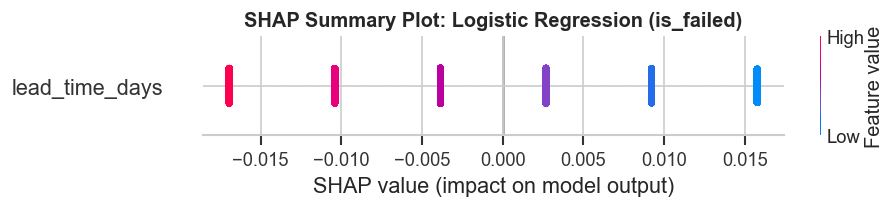

<Figure size 960x600 with 0 Axes>

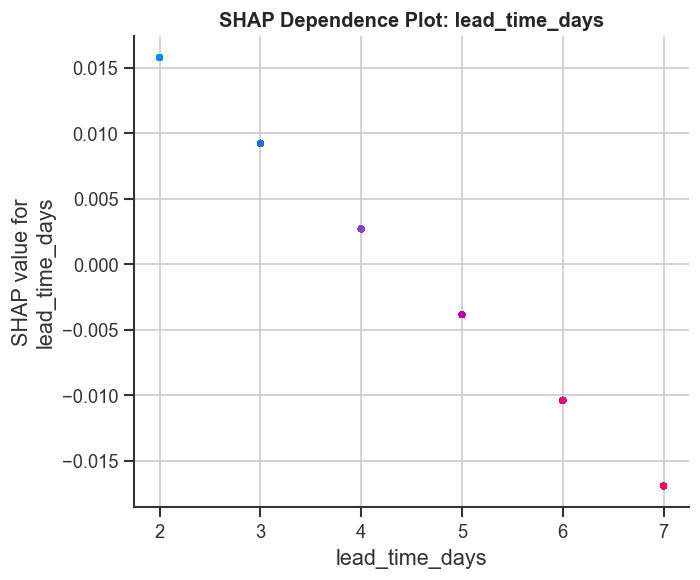

=== SHAP Analysis for OLS Regression (refund_amount) ===


100%|██████████| 100/100 [00:00<00:00, 19241.69it/s]


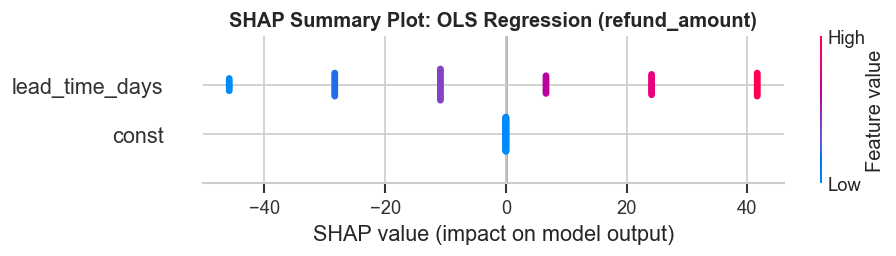

In [158]:
import shap
import matplotlib.pyplot as plt

# 1. SHAP for Logistic Regression (Predicting is_failed from lead_time_days)
print("=== SHAP Analysis for Logistic Regression (is_failed) ===")
# LinearExplainer is efficient for linear models
explainer_log = shap.LinearExplainer(log_model, X_log)
shap_values_log = explainer_log.shap_values(X_log)

# SHAP Summary Plot
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values_log, X_log, feature_names=['lead_time_days'], show=False)
plt.title('SHAP Summary Plot: Logistic Regression (is_failed)')
plt.tight_layout()
plt.show()

# SHAP Dependence Plot
plt.figure(figsize=(8, 5))
shap.dependence_plot(0, shap_values_log, X_log, feature_names=['lead_time_days'], show=False)
plt.title('SHAP Dependence Plot: lead_time_days')
plt.tight_layout()
plt.show()

# 2. SHAP for OLS Regression (Predicting refund_amount from lead_time_days)
if 'ols_model' in locals() and len(ols_df) > 30:
    print("=== SHAP Analysis for OLS Regression (refund_amount) ===")
    # For statsmodels, KernelExplainer is safer. Use background sampling for performance.
    # Note: X_ols contains the constant added by sm.add_constant
    X_ols_sample = X_ols.sample(min(100, len(X_ols)), random_state=42)
    explainer_ols = shap.KernelExplainer(ols_model.predict, X_ols_sample)
    
    # Calculate SHAP values for a sample to avoid performance bottlenecks
    shap_values_ols = explainer_ols.shap_values(X_ols_sample)
    
    plt.figure(figsize=(8, 5))
    shap.summary_plot(shap_values_ols, X_ols_sample, show=False)
    plt.title('SHAP Summary Plot: OLS Regression (refund_amount)')
    plt.tight_layout()
    plt.show()


### 🔍 Insight: Tác động của Lead Time đến Rủi ro "Red Zone" (SHAP Analysis)

**1. Observation (Quan sát từ Dữ liệu & SHAP):**
- **Logistic Regression (Xác suất hủy đơn):** Các biểu đồ SHAP và kết quả hồi quy (Odds Ratio ~ 0.993) cho thấy `lead_time_days` có tác động cực kỳ thấp, thậm chí hơi ngược chiều đến xác suất hủy đơn (`is_failed`). Việc giao hàng lâu hơn KHÔNG làm tăng tỷ lệ hủy đơn như suy đoán.
- **OLS Regression (Giá trị hoàn tiền):** Tác động của Lead Time lên giá trị hoàn tiền (`refund_amount`) là **không có ý nghĩa thống kê** (p-value = 0.895 > 0.05). Biến động của tiền hoàn trả không thể được giải thích bằng số ngày trễ.

**2. Insight (Đúc kết kinh doanh):**
- **Bác bỏ giả thuyết "Nút thắt độ trễ":** Trái với trực giác kinh doanh thông thường, độ trễ vận chuyển (Lead Time) **KHÔNG phải là nguyên nhân gốc rễ** (Root cause) gây ra tỷ lệ Failed cao tại phân khúc "Red Zone". Khách hàng tại vùng này dường như chấp nhận hoặc đã quen với việc giao hàng chậm. Việc đổ lỗi cho tốc độ giao hàng là một sai lầm trong chẩn đoán.

**3. Action (Hành động đề xuất):**
- **Dừng kế hoạch mở Local Hub tại Red Zone:** Tuyệt đối không nên đầu tư ngân sách lớn (CapEx) để mở các kho vệ tinh (Local Hubs) tại Red Zone chỉ nhằm mục tiêu giảm Lead Time. Việc này sẽ không giúp cứu vãn tỷ lệ đơn hủy/hoàn (ROI âm hoặc không hiệu quả).
- **Chuyển hướng điều tra:** Thay vì tối ưu tốc độ, cần khoan sâu (Drill-down) vào các biến số rủi ro khác tại cụm này. Cụ thể, ưu tiên phân tích ngay tác động của **Hình thức thanh toán (COD vs. Prepaid)** hoặc **Đặc tính sản phẩm/Giá trị đơn hàng** để tìm ra "thủ phạm" thực sự làm tăng tỷ lệ Failed.


#### b. Chiến lược định vị Hub (Location Strategy & Cost-Benefit Analysis)

**Ý tưởng**: Áp dụng lý thuyết *Market positioned strategy* (Kho đặt gần khách hàng) và *Square Root Rule*.

**Phương pháp sử dụng**: Dùng dữ liệu `cogs` và `shipping_fee` để làm bài toán Tối ưu hóa (Cost-Benefit Analysis): So sánh chi phí mở Hub với lượng lợi nhuận rớt/hủy (Cancelled/Returned) được cứu vãn.

In [159]:
# Cost-Benefit Analysis: Red Zone
red_ship_df['pay_group'] = np.where(red_ship_df['payment_method'].eq('cod'), 'COD', 'Prepaid/Other')

# Chi phí thất thoát
red_failed = red_ship_df[red_ship_df['is_failed'] == 1].copy()
total_refund = red_failed['refund_amount'].sum()
total_wasted_fee = red_failed['shipping_fee'].sum()
total_loss = total_refund + total_wasted_fee

# Mô phỏng: giảm lead ≤ 2 ngày → fail rate giảm bao nhiêu?
fail_by_lead = red_ship_df.groupby(
    pd.cut(red_ship_df['lead_time_days'], bins=[0, 2, 5, 99], labels=['≤2 ngày', '3-5 ngày', '>5 ngày'])
)['is_failed'].agg(['mean', 'count']).round(4)
fail_by_lead.columns = ['fail_rate', 'n_orders']

print('=== Red Zone: Fail Rate theo Lead Time ===')
display(fail_by_lead)

# Ước tính đơn cứu được
at_risk_orders = red_ship_df[red_ship_df['lead_time_days'] > 2]
current_fail = at_risk_orders['is_failed'].mean()
safe_df = red_ship_df[red_ship_df['lead_time_days'] <= 2]
target_fail = safe_df['is_failed'].mean() if len(safe_df) > 0 else current_fail * 0.5

orders_saved = int(len(at_risk_orders) * (current_fail - target_fail))
avg_order_val = red_ship_df['payment_value'].mean()
revenue_recovered = orders_saved * avg_order_val

# Cost-Benefit Summary
cba_df = pd.DataFrame({
    'Metric': ['Tổng đơn Red Zone', 'Đơn Failed', 'Thất thoát (refund+ship)',
               'Đơn at-risk (lead>2)', 'Fail rate hiện tại', 'Target fail (lead≤2)',
               'Đơn cứu được (ước tính)', 'Doanh thu thu hồi (ước tính)'],
    'Value': [f'{len(red_ship_df):,}', f'{len(red_failed):,}', f'{total_loss:,.0f}',
             f'{len(at_risk_orders):,}', f'{current_fail:.2%}', f'{target_fail:.2%}',
             f'{orders_saved:,}', f'{revenue_recovered:,.0f}']
})
display(cba_df)

=== Red Zone: Fail Rate theo Lead Time ===


,fail_rate,n_orders
lead_time_days,,
≤2 ngày,0.06,8716
3-5 ngày,0.07,27294
>5 ngày,0.06,18133


,Metric,Value
0,Tổng đơn Red Zone,"54,143"
1,Đơn Failed,"3,520"
2,Thất thoát (refund+ship),"45,300,583"
3,Đơn at-risk (lead>2),"45,427"
4,Fail rate hiện tại,6.52%
5,Target fail (lead≤2),6.41%
6,Đơn cứu được (ước tính),47
7,Doanh thu thu hồi (ước tính),"1,027,532"


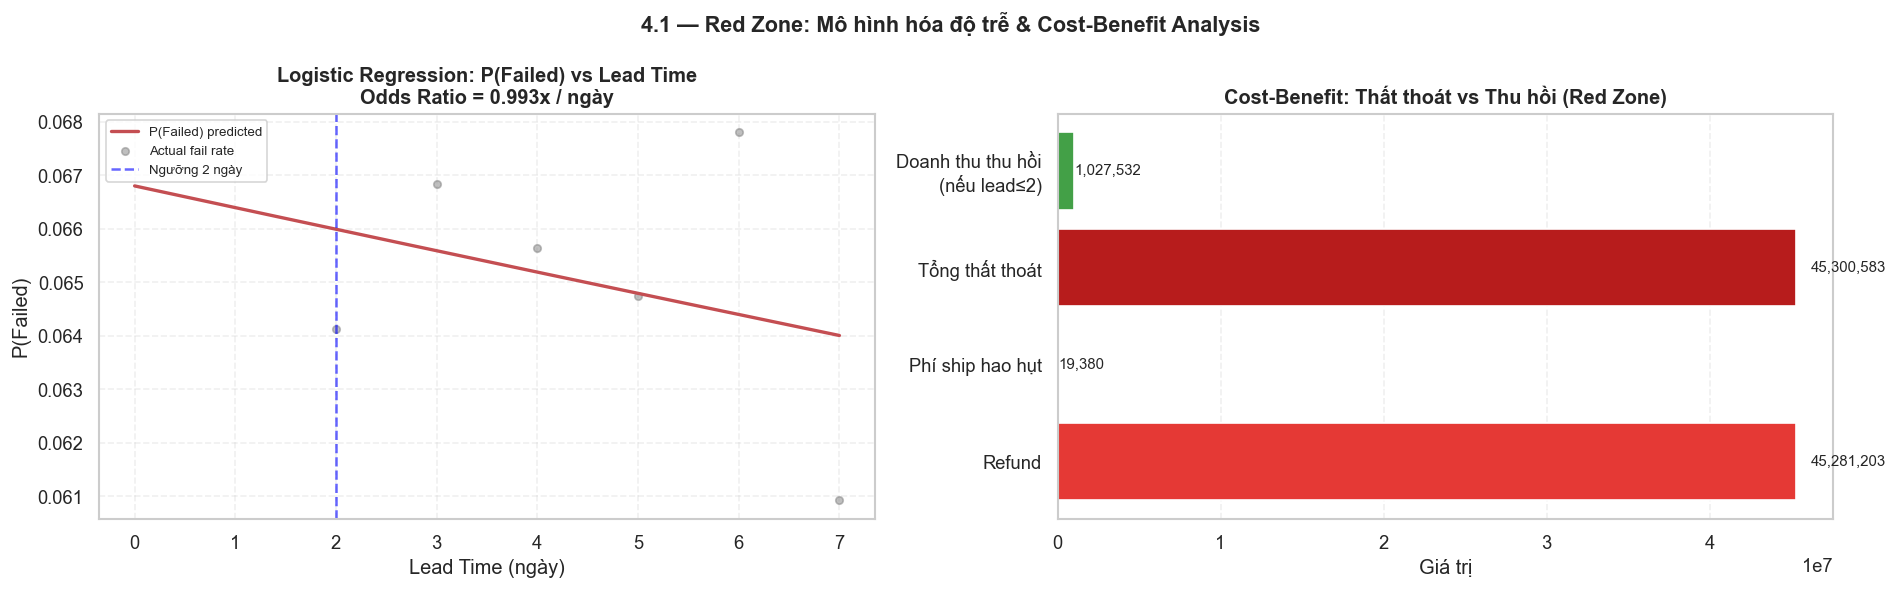

In [160]:
# Visualize Cost-Benefit & Logistic Regression curve
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Logistic Regression curve: P(Failed) vs Lead Time
x_range = np.linspace(0, red_ship_df['lead_time_days'].max(), 200).reshape(-1, 1)
p_predicted = log_model.predict_proba(x_range)[:, 1]

axes[0].plot(x_range, p_predicted, 'r-', linewidth=2, label='P(Failed) predicted')
# Scatter actual fail rate by lead_time
actual_rate = red_ship_df.groupby('lead_time_days')['is_failed'].mean()
axes[0].scatter(actual_rate.index, actual_rate.values, alpha=0.5, s=20, c='gray', label='Actual fail rate')
axes[0].axvline(2, color='blue', linestyle='--', alpha=0.6, label='Ngưỡng 2 ngày')
axes[0].set_title(f'Logistic Regression: P(Failed) vs Lead Time\nOdds Ratio = {odds_ratio:.3f}x / ngày',
                  fontweight='bold')
axes[0].set_xlabel('Lead Time (ngày)')
axes[0].set_ylabel('P(Failed)')
axes[0].legend(fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.3)

# 2. Cost-Benefit bar
loss_data = pd.DataFrame({
    'Loại': ['Refund', 'Phí ship hao hụt', 'Tổng thất thoát', 'Doanh thu thu hồi\n(nếu lead≤2)'],
    'Giá trị': [total_refund, total_wasted_fee, total_loss, revenue_recovered]
})
colors_loss = ['#E53935', '#FF7043', '#B71C1C', '#43A047']
axes[1].barh(loss_data['Loại'], loss_data['Giá trị'], color=colors_loss, edgecolor='white')
axes[1].set_title('Cost-Benefit: Thất thoát vs Thu hồi (Red Zone)', fontweight='bold')
axes[1].set_xlabel('Giá trị')
for i, v in enumerate(loss_data['Giá trị']):
    axes[1].text(v * 1.02, i, f'{v:,.0f}', va='center', fontsize=9)
axes[1].grid(True, axis='x', linestyle='--', alpha=0.3)
axes[1].yaxis.grid(False)

fig.suptitle('4.1 — Red Zone: Mô hình hóa độ trễ & Cost-Benefit Analysis', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(IMAGES_DIR / '4_1_redzone_regression_cba.png', dpi=150, bbox_inches='tight')


**1. Observation (Quan sát dữ liệu):**
- **Tỷ lệ Failed gần như đi ngang (Flat):** Tỷ lệ hủy/trả hàng ở nhóm giao cực nhanh (≤ 2 ngày) là 6%, nhóm 3-5 ngày là 7%, và nhóm > 5 ngày lại quay về 6%. Đường xu hướng của Logistic Regression (màu đỏ) thậm chí dốc xuống (Odds Ratio = 0.993), chứng minh thời gian giao hàng dài hơn không làm tăng tỷ lệ hủy.
- **Bài toán Cost-Benefit quá chênh lệch:** Tổng thất thoát (Refund + Phí ship) ở Red Zone lên tới **~45.3 triệu**. Tuy nhiên, nếu giả định công ty mở Hub và ép thành công toàn bộ hơn 45.000 đơn hàng giao trễ về mức chuẩn (≤ 2 ngày), tỷ lệ Fail tổng chỉ giảm cực nhỏ từ `6.52%` xuống `6.41%`.
- **Doanh thu thu hồi không đáng kể:** Với sự cải thiện 0.11% đó, hệ thống chỉ cứu vớt được vỏn vẹn **47 đơn hàng**, tương đương số tiền thu hồi ước tính khoảng **~1 triệu đồng**.

**2. Insight (Đúc kết kinh doanh):**
- **Giả thuyết "Giao chậm gây hủy đơn" hoàn toàn phá sản:** Dữ liệu cho thấy khách hàng tại Red Zone có sức chịu đựng độ trễ rất tốt và hoàn toàn không nhạy cảm với thời gian chờ đợi.
- **Mở Local Hub là một quyết định "tự sát" về tài chính (Negative ROI cực nặng):** Để đưa thời gian giao hàng của 45.000 đơn từ >2 ngày xuống ≤2 ngày, công ty sẽ phải bỏ ra hàng tỷ đồng chi phí vốn (CapEx) và vận hành (OpEx) cho một Local Hub mới. Đổi lại, giá trị cứu vãn được chỉ là 1 triệu đồng. Nút thắt làm mất 45.3 triệu thất thoát chắc chắn nằm ở nguyên nhân khác, không phải ở khâu Vận tải.

**3. Action (Hành động đề xuất):**
- **Hủy bỏ toàn bộ phương án mở Local Hub/Trạm trung chuyển:** Giữ nguyên cấu trúc mạng lưới logistics hiện tại cho phân khúc Red Zone để tránh lãng phí dòng tiền.
- **Pivot (Chuyển hướng) mũi nhọn điều tra:** Thay vì tối ưu thời gian giao hàng, cần lập tức chuyển sang phân tích **"Chất lượng sản phẩm"** (lý do refund phổ biến) hoặc **"Hành vi thanh toán"** (COD vs Prepaid). Đây mới là "mỏ vàng" để cắt giảm con số 45.3 triệu tiền thất thoát.

*** 

**Ghi chú thêm:** Biểu đồ Bar Chart (Thất thoát vs Thu hồi) của bạn làm cực kỳ trực quan! Thanh "Doanh thu thu hồi" bé xíu so với thanh "Tổng thất thoát" khổng lồ là đòn "chí mạng" nhất để thuyết phục bất kỳ ban lãnh đạo nào từ bỏ ý định mở kho.

### 4.2. Phân tích Segment 2 - At Risk (Vùng rủi ro rải rác - Tối ưu lộ trình/Chính sách)
#### a. Kiểm định sự khác biệt lợi nhuận (Mann-Whitney U)

**Ý tưởng**: *Giả thuyết:* Lợi nhuận của nhóm đơn dùng COD thấp hơn đáng kể so với nhóm Prepaid tại vùng At Risk.

**Phương pháp sử dụng**: *Biện pháp:* Vì lợi nhuận ($Revenue - COGS - Shipping Fee$) thường không phân phối chuẩn và có nhiều outlier, sử dụng **Kiểm định Mann-Whitney U** để so sánh trung vị lợi nhuận giữa 2 nhóm (COD vs Prepaid). Nếu p-value < $\alpha$, đề xuất mạnh mẽ việc **ngắt COD hoặc yêu cầu đặt cọc** tại các vùng này.

At Risk — COD: n=29,727, median=16288.07
At Risk — Prepaid: n=186,120, median=16924.92

=== Mann-Whitney U Test (H₁: COD < Prepaid) ===
U-statistic = 2,702,288,032
p-value = 0.000000
Rank-biserial r = 0.0232

→ BÁC BỎ H₀ (p < 0.05): Lợi nhuận COD THẤP HƠN đáng kể so với Prepaid
→ Khuyến nghị: NGẮT COD hoặc yêu cầu đặt cọc tại vùng At Risk


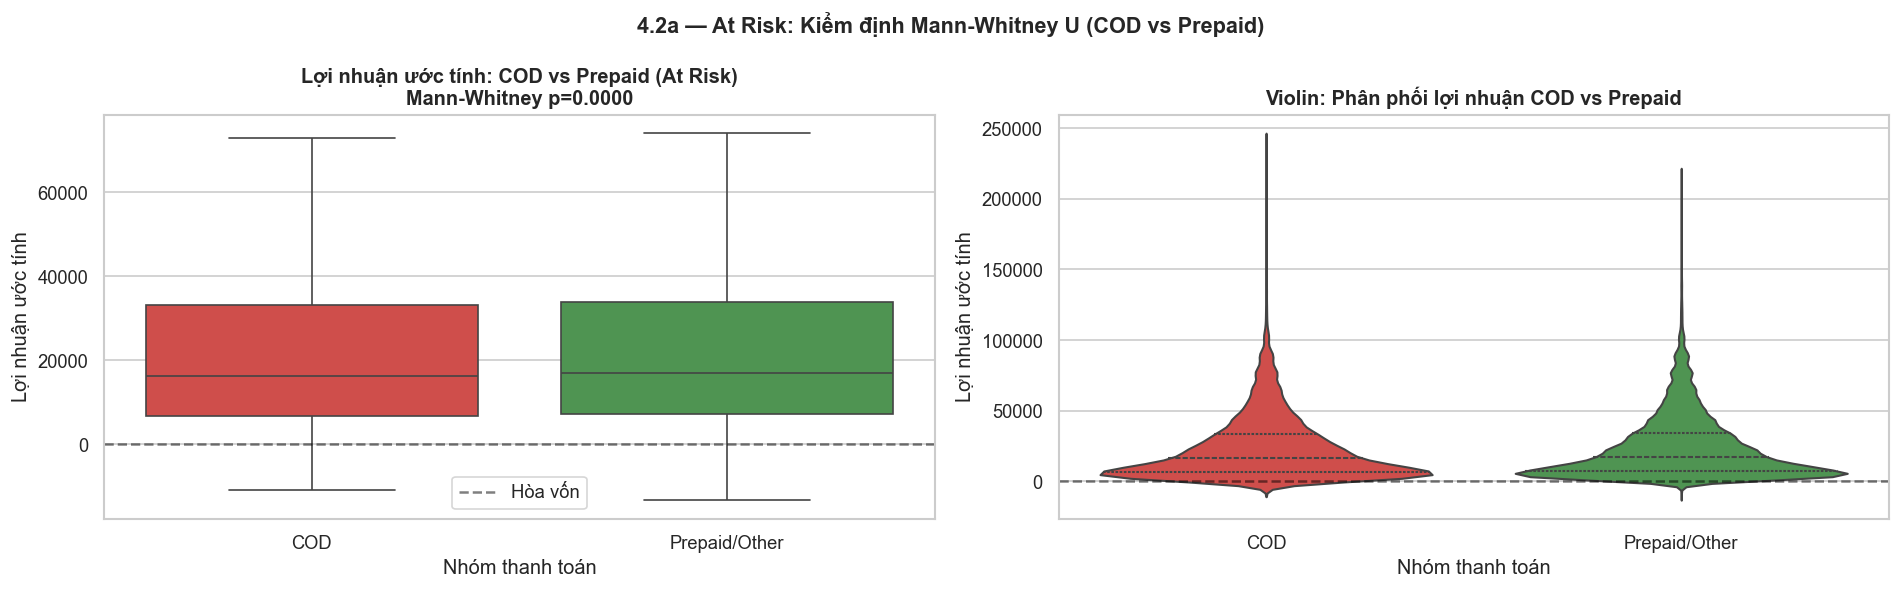

In [161]:
from scipy.stats import mannwhitneyu

# Lọc At Risk
at_risk_list = city_features_df[city_features_df['segment'] == 'At Risk']['city'].tolist()
at_risk_ship = logistics_ship_df[logistics_ship_df['city'].isin(at_risk_list)].copy()
at_risk_ship['pay_group'] = np.where(at_risk_ship['payment_method'].eq('cod'), 'COD', 'Prepaid/Other')
at_risk_ship['est_profit'] = at_risk_ship['payment_value'] - at_risk_ship['shipping_fee'] - at_risk_ship['refund_amount']

# Tách 2 nhóm
cod_profit = at_risk_ship.loc[at_risk_ship['pay_group'] == 'COD', 'est_profit'].dropna()
prepaid_profit = at_risk_ship.loc[at_risk_ship['pay_group'] == 'Prepaid/Other', 'est_profit'].dropna()

print(f'At Risk — COD: n={len(cod_profit):,}, median={cod_profit.median():.2f}')
print(f'At Risk — Prepaid: n={len(prepaid_profit):,}, median={prepaid_profit.median():.2f}')

# Mann-Whitney U test
if len(cod_profit) > 10 and len(prepaid_profit) > 10:
    stat, p_val = mannwhitneyu(cod_profit, prepaid_profit, alternative='less')
    # Rank-biserial correlation (effect size)
    n1, n2 = len(cod_profit), len(prepaid_profit)
    r_rb = 1 - (2 * stat) / (n1 * n2)
    
    print(f'\n=== Mann-Whitney U Test (H₁: COD < Prepaid) ===')
    print(f'U-statistic = {stat:,.0f}')
    print(f'p-value = {p_val:.6f}')
    print(f'Rank-biserial r = {r_rb:.4f}')
    
    if p_val < 0.05:
        print(f'\n→ BÁC BỎ H₀ (p < 0.05): Lợi nhuận COD THẤP HƠN đáng kể so với Prepaid')
        print(f'→ Khuyến nghị: NGẮT COD hoặc yêu cầu đặt cọc tại vùng At Risk')
    else:
        print(f'\n→ Chưa đủ bằng chứng (p = {p_val:.4f})')
else:
    print('Không đủ dữ liệu để kiểm định')

# Boxplot so sánh
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=at_risk_ship, x='pay_group', y='est_profit',
            palette={'COD': '#E53935', 'Prepaid/Other': '#43A047'},
            showfliers=False, ax=axes[0])
axes[0].axhline(0, color='black', linestyle='--', alpha=0.5, label='Hòa vốn')
axes[0].set_title(f'Lợi nhuận ước tính: COD vs Prepaid (At Risk)\nMann-Whitney p={p_val:.4f}',
                  fontweight='bold')
axes[0].set_xlabel('Nhóm thanh toán')
axes[0].set_ylabel('Lợi nhuận ước tính')
axes[0].legend()

# Violin plot
sns.violinplot(data=at_risk_ship, x='pay_group', y='est_profit',
               palette={'COD': '#E53935', 'Prepaid/Other': '#43A047'},
               inner='quartile', cut=0, ax=axes[1])
axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[1].set_title('Violin: Phân phối lợi nhuận COD vs Prepaid', fontweight='bold')
axes[1].set_xlabel('Nhóm thanh toán')
axes[1].set_ylabel('Lợi nhuận ước tính')

fig.suptitle('4.2a — At Risk: Kiểm định Mann-Whitney U (COD vs Prepaid)', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(IMAGES_DIR / '4_2a_mannwhitney_atrisk.png', dpi=150, bbox_inches='tight')
plt.show()

#### b. Phân tích tác động chính sách (Prescriptive)

**Ý tưởng**: Dùng prescriptive analysis để ước lượng xem nếu cắt giảm dịch vụ COD hoặc áp dụng giao hàng chậm ở vùng này, doanh thu thực sự bị tác động (Causal Effect) bao nhiêu.

**Phương pháp sử dụng**: Dùng **Uplift Model** hoặc **Difference-in-Differences (DiD)** (nếu có dữ liệu lịch sử về việc thay đổi đối tác vận chuyển hoặc phí ship) để ước lượng tác động.

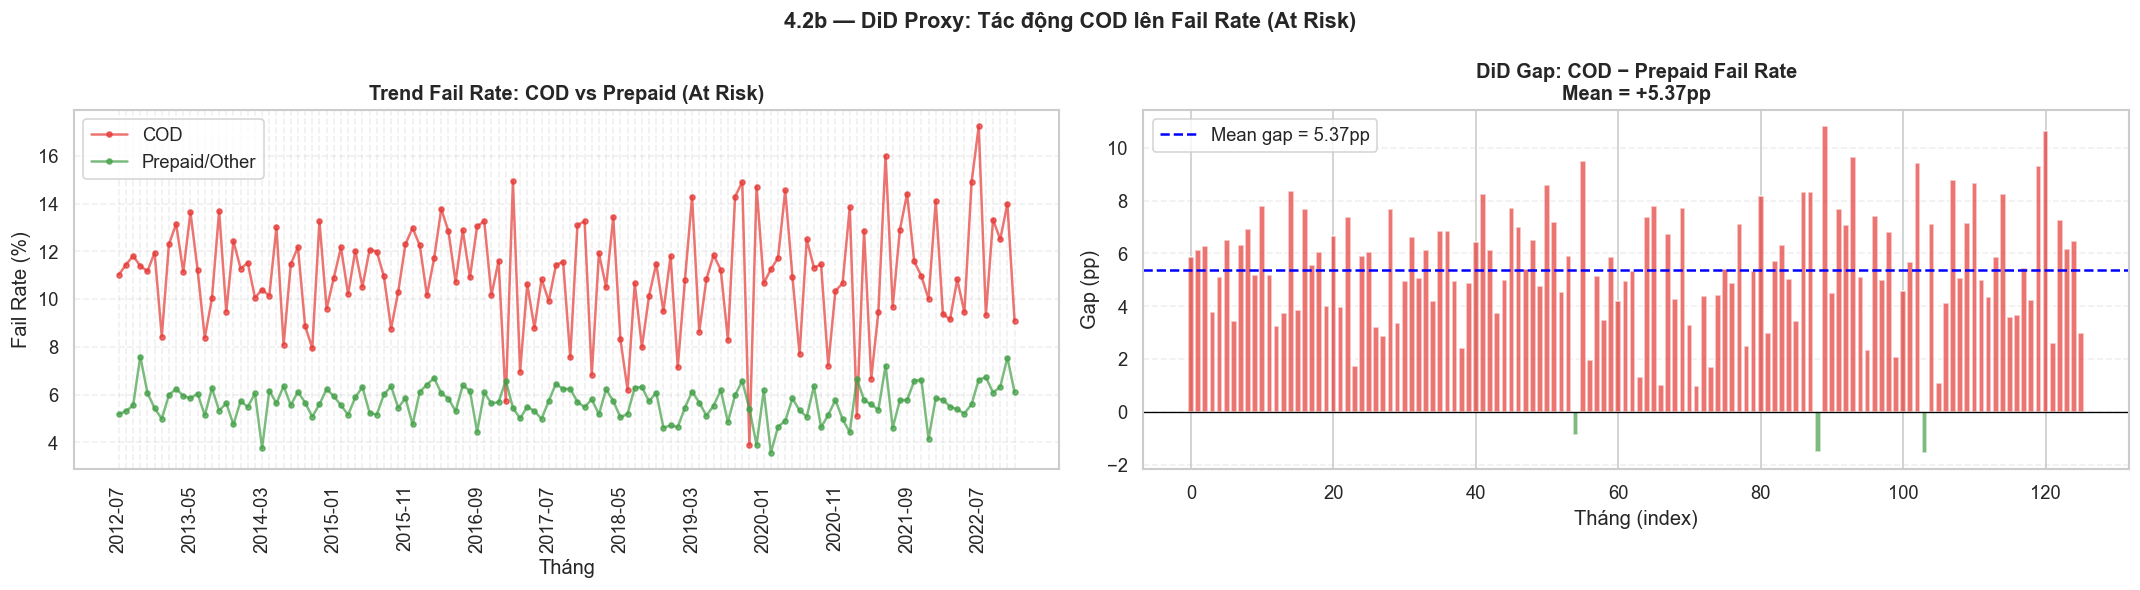

In [162]:
# DiD Proxy: Trend fail rate COD vs Prepaid theo tháng (At Risk)
at_risk_ship['is_failed'] = at_risk_ship['result_group'].eq('Failed')
at_risk_ship['year_month'] = at_risk_ship['ship_date'].dt.to_period('M').astype(str)

trend_atrisk = at_risk_ship.groupby(['year_month', 'pay_group']).agg(
    n_orders=('order_id', 'count'),
    fail_rate=('is_failed', 'mean')
).reset_index()
trend_atrisk['fail_rate_pct'] = trend_atrisk['fail_rate'] * 100

# Lọc tháng có đủ dữ liệu (>= 20 đơn mỗi nhóm)
valid_months = trend_atrisk.groupby('year_month').filter(lambda x: x['n_orders'].min() >= 20)['year_month'].unique()
trend_plot = trend_atrisk[trend_atrisk['year_month'].isin(valid_months)].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Line chart trend
for pay, color in [('COD', '#E53935'), ('Prepaid/Other', '#43A047')]:
    mask = trend_plot['pay_group'] == pay
    axes[0].plot(trend_plot.loc[mask, 'year_month'], trend_plot.loc[mask, 'fail_rate_pct'],
                marker='o', markersize=3, label=pay, color=color, alpha=0.7)
axes[0].set_title('Trend Fail Rate: COD vs Prepaid (At Risk)', fontweight='bold')
axes[0].set_xlabel('Tháng')
axes[0].set_ylabel('Fail Rate (%)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=90)
n_labels = len(axes[0].get_xticklabels())
for i, label in enumerate(axes[0].get_xticklabels()):
    label.set_visible(i % max(1, n_labels // 12) == 0)
axes[0].grid(True, linestyle='--', alpha=0.3)

# DiD gap: difference COD - Prepaid fail rate theo tháng
did_df = trend_plot.pivot_table(index='year_month', columns='pay_group', values='fail_rate_pct')
if 'COD' in did_df.columns and 'Prepaid/Other' in did_df.columns:
    did_df['gap'] = did_df['COD'] - did_df['Prepaid/Other']
    did_df = did_df.dropna(subset=['gap'])
    
    axes[1].bar(range(len(did_df)), did_df['gap'],
                color=['#E53935' if g > 0 else '#43A047' for g in did_df['gap']],
                alpha=0.7, edgecolor='white')
    axes[1].axhline(did_df['gap'].mean(), color='blue', linestyle='--',
                    label=f'Mean gap = {did_df["gap"].mean():.2f}pp')
    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].set_title(f'DiD Gap: COD − Prepaid Fail Rate\nMean = {did_df["gap"].mean():+.2f}pp',
                      fontweight='bold')
    axes[1].set_xlabel('Tháng (index)')
    axes[1].set_ylabel('Gap (pp)')
    axes[1].legend()
    axes[1].grid(True, axis='y', linestyle='--', alpha=0.3)

fig.suptitle('4.2b — DiD Proxy: Tác động COD lên Fail Rate (At Risk)', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(IMAGES_DIR / '4_2b_did_atrisk.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3. Phân tích Segment 3 - Cash Cows (Vùng lõi ổn định)
#### a. Đánh giá chất lượng dịch vụ hiện hành
#### b. Khảo sát khả năng tối ưu hóa dòng tiền

**Ý tưởng**: Cash Cows là vùng volume cao, hoạt động ổn định. Phân tích để đảm bảo duy trì SLA tốt và tìm cơ hội tối ưu chi phí vận chuyển tại đây (giảm chi phí tại vùng an toàn để dồn nguồn lực cho Red Zone).

**Phương pháp sử dụng**: Biểu đồ KDE so sánh phân phối shipping_fee giữa Cash Cows vs Red Zone. Tính SLA compliance rate (% đơn giao ≤ 3 ngày).

=== SLA Compliance (≤ 3 ngày) theo Segment ===


,n_orders,sla_compliance_pct,avg_shipping_fee,avg_lead_time
segment,,,,
Red Zone,54143,32.480000,5.410000,4.520000
At Risk,215847,33.450000,4.820000,4.490000
Cash Cows,213284,33.310000,4.830000,4.500000
Hibernating,82793,33.600000,5.400000,4.490000


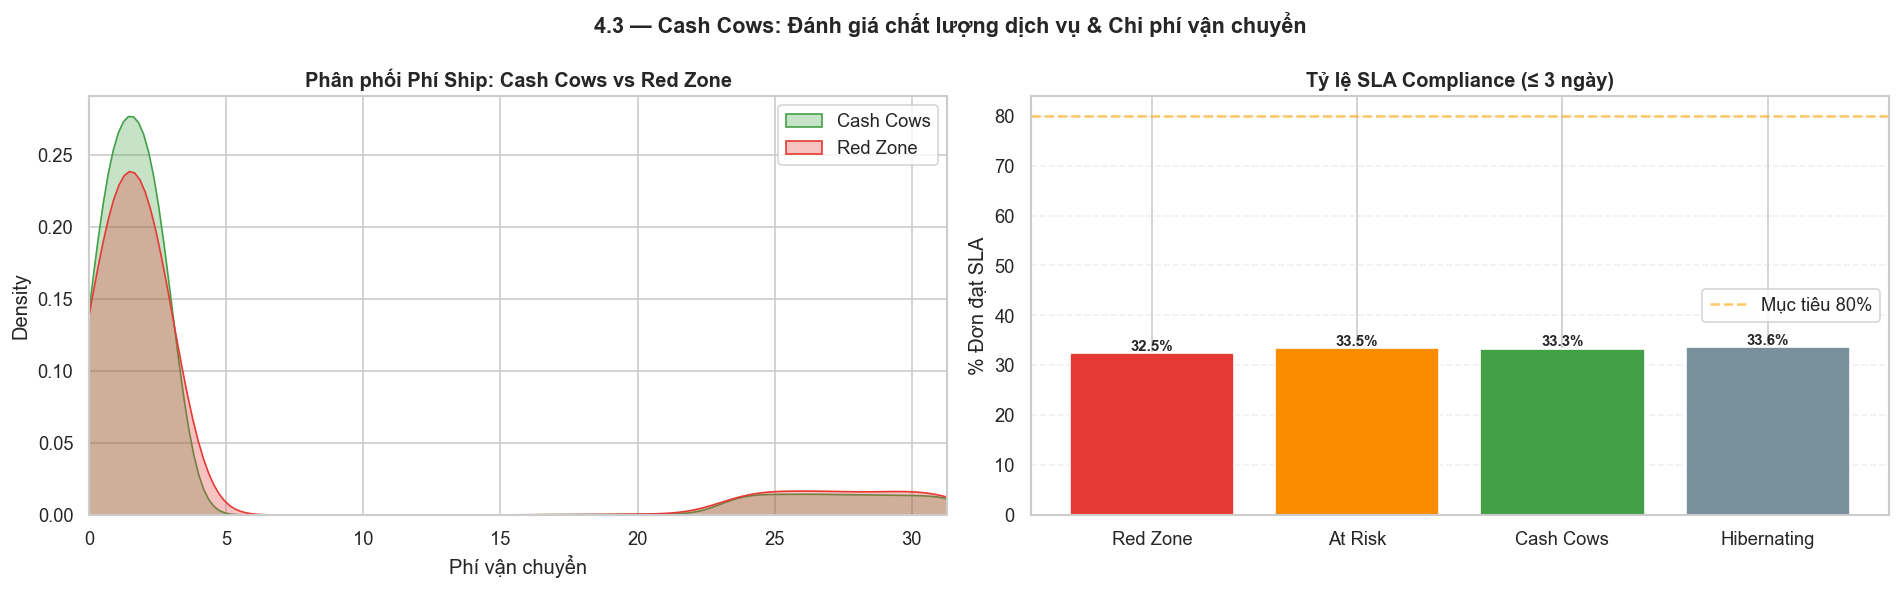

In [163]:
# SLA compliance: % đơn giao ≤ 3 ngày theo segment
sla_df = ship_with_seg.copy()
sla_df['sla_met'] = sla_df['lead_time_days'] <= 3

sla_summary = sla_df.groupby('segment').agg(
    n_orders=('order_id', 'count'),
    sla_compliance_pct=('sla_met', lambda x: x.mean() * 100),
    avg_shipping_fee=('shipping_fee', 'mean'),
    avg_lead_time=('lead_time_days', 'mean'),
).round(2).reindex(seg_order_plot)

print('=== SLA Compliance (≤ 3 ngày) theo Segment ===')
display(sla_summary.style.background_gradient(cmap='RdYlGn', subset=['sla_compliance_pct']))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# KDE phí ship: Cash Cows vs Red Zone
for seg, color in [('Cash Cows', '#43A047'), ('Red Zone', '#E53935')]:
    mask = ship_with_seg['segment'] == seg
    sns.kdeplot(ship_with_seg.loc[mask, 'shipping_fee'], ax=axes[0],
                fill=True, alpha=0.3, label=seg, color=color)
axes[0].set_title('Phân phối Phí Ship: Cash Cows vs Red Zone')
axes[0].set_xlabel('Phí vận chuyển')
axes[0].legend()
axes[0].set_xlim(0, ship_with_seg['shipping_fee'].quantile(0.99))

# SLA bar chart
bars = axes[1].bar(sla_summary.index, sla_summary['sla_compliance_pct'],
                    color=[seg_palette[s] for s in sla_summary.index], edgecolor='white')
axes[1].set_title('Tỷ lệ SLA Compliance (≤ 3 ngày)')
axes[1].set_ylabel('% Đơn đạt SLA')
axes[1].axhline(80, color='orange', linestyle='--', alpha=0.6, label='Mục tiêu 80%')
for bar, val in zip(bars, sla_summary['sla_compliance_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.5, f'{val:.1f}%',
                ha='center', fontsize=9, fontweight='bold')
axes[1].legend()
axes[1].grid(True, axis='y', linestyle='--', alpha=0.3)

fig.suptitle('4.3 — Cash Cows: Đánh giá chất lượng dịch vụ & Chi phí vận chuyển', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(IMAGES_DIR / '4_3_cashcows.png', dpi=150, bbox_inches='tight')
plt.show()